In [1]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import mplhep as hep
hep.style.use("ATLAS")

In [2]:
fold  = "fold0"
# ckpt_files = glob.glob(f"./hww_pcres_regressor_kfold/{fold}/version_0/checkpoints/*.ckpt")
ckpt_files = glob.glob(f"./hww_pcres_regressor_nofold/logs/version_0/checkpoints/*.ckpt")
print(f"Found checkpoint files: {ckpt_files}")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Found checkpoint files: ['./hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=300-val_loss=23.85.ckpt']
Using checkpoint: ./hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=300-val_loss=23.85.ckpt


In [3]:
# Retrieve datamodule used in training
# train = two_fold_train
dm = train.main(train=False)
# Load model from checkpoint
model = LightningWBoson.load_from_checkpoint(ckpt_path, weights_only=False, strict=False)
model.eval() # used to inference -> not for training phase

# Set up the data module (prepare data and setup splits)
dm.setup(stage="test")  # Ensure test dataset is ready
# Get the test dataloader
test_loader = dm.test_dataloader()

# Run inference
train_features = np.zeros([0, dm.X.shape[1]])
predictions = np.zeros([0, dm.Y.shape[1]-2]) # without including W0 and W1 mass
true_labels = np.zeros([0, dm.Y.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():  # Disable gradient computation for inference
    for batch in test_loader:
        # Assuming batch contains inputs and targets
        inputs, targets = batch
        # print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Store predictions and true labels
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...
Training objects shape: (376985, 32)
Target objects shape: (376985, 10)
Removed 0 rows with NaN or infinite values
Using 4 num of workers in data loading.
Using random split (val_frac / test_frac)
Loading model from checkpoint for evaluation... return datamodule
Using 2 SA blocks.
Using random split (val_frac / test_frac)


In [4]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]
true_met_px = train_features[:, 20]
true_met_py = train_features[:, 21]

In [5]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

In [6]:
def rel_err_func(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return (a[mask] - b[mask]) / b[mask]


In [7]:
def err_bounds(x, rel_err=0.2, offset=5.0):
    delta = rel_err * np.abs(x) + offset
    upper = x + delta
    lower = x - delta
    return upper, lower

In [8]:
def rmse(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return np.sqrt(np.mean((a[mask] - b[mask]) ** 2))

In [9]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=1e2, offset=0.0, savepath=None):
    err = 0.2
    cor_mask = np.abs(rel_err_func(pred, truth)) <= err # set 20% relative error cut
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
        
    # Plot error guides aligned with bin edges
    upper, lower = err_bounds(bins_edges, rel_err=err, offset=offset)
    plt.plot(upper, bins_edges, color="gainsboro", linestyle="-", label=r"$\pm 20\% offset$")
    plt.plot(bins_edges, bins_edges, color="gainsboro", linestyle="--")
    plt.plot(lower, bins_edges, color="gainsboro", linestyle="-")
    
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}"+f" with RMSE: {rmse(pred, truth):.2f}", loc="right")
    print(f"Rel err < 20%: {100*np.sum(cor_mask)/len(truth):.2f} %")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_244313/3354150173.py:10: RuntimeWarning: invalid value encountered in sqrt
  true_higgs_mass = np.sqrt(true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2))


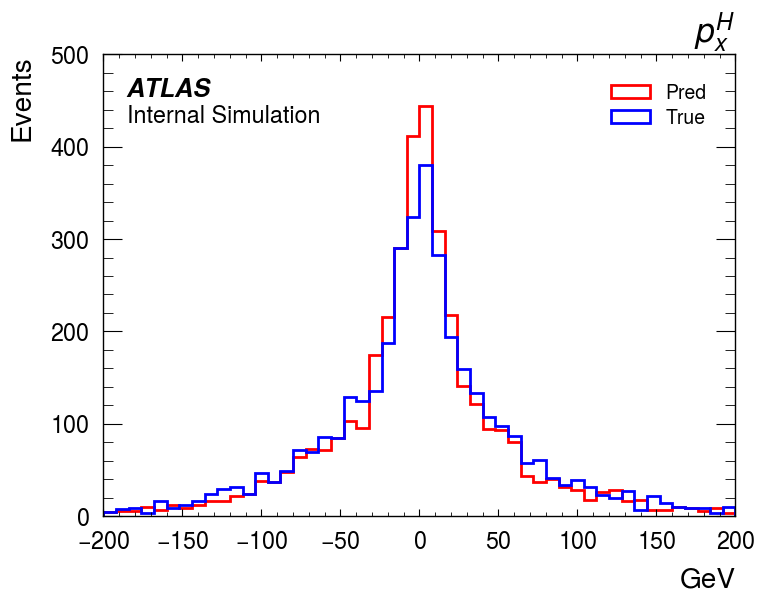

Rel err < 20%: 27.33 %


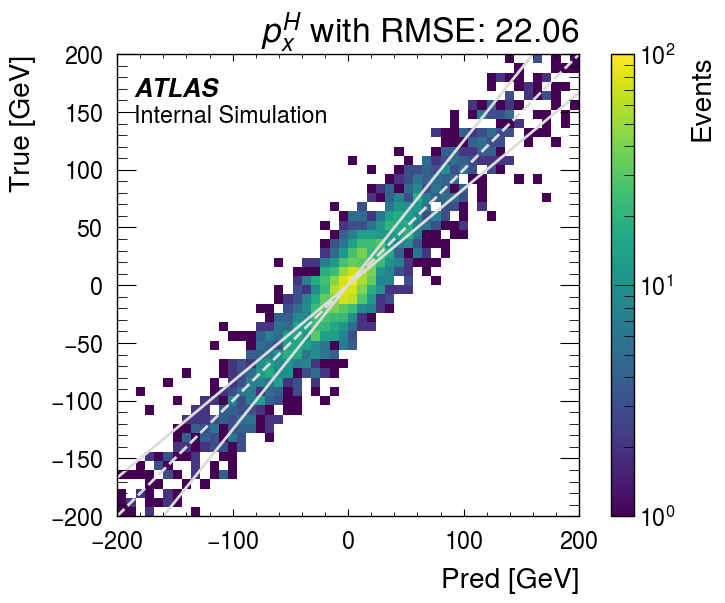

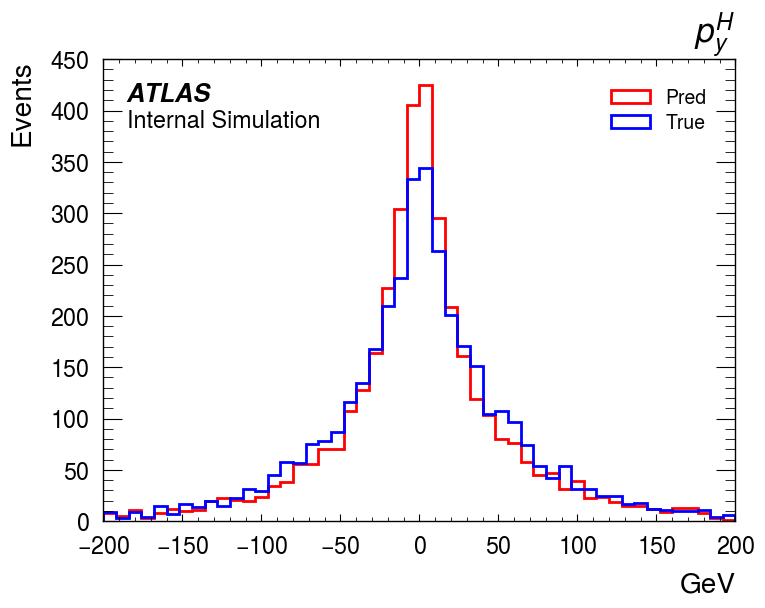

Rel err < 20%: 27.49 %


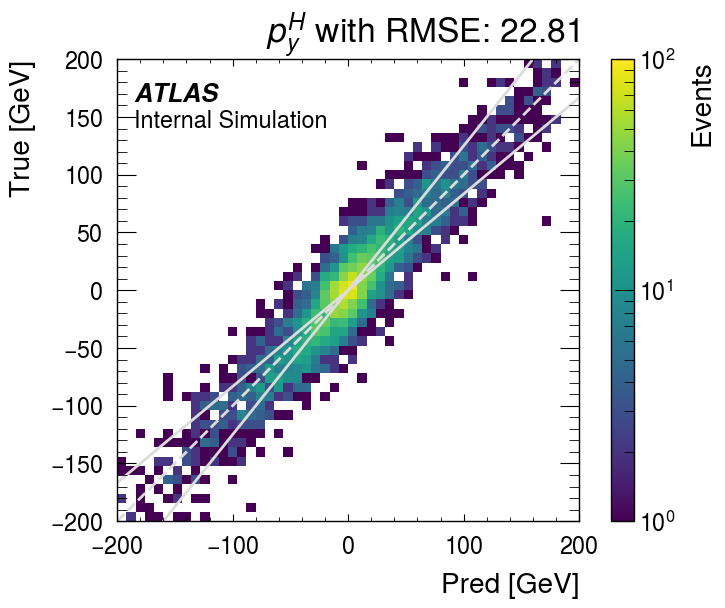

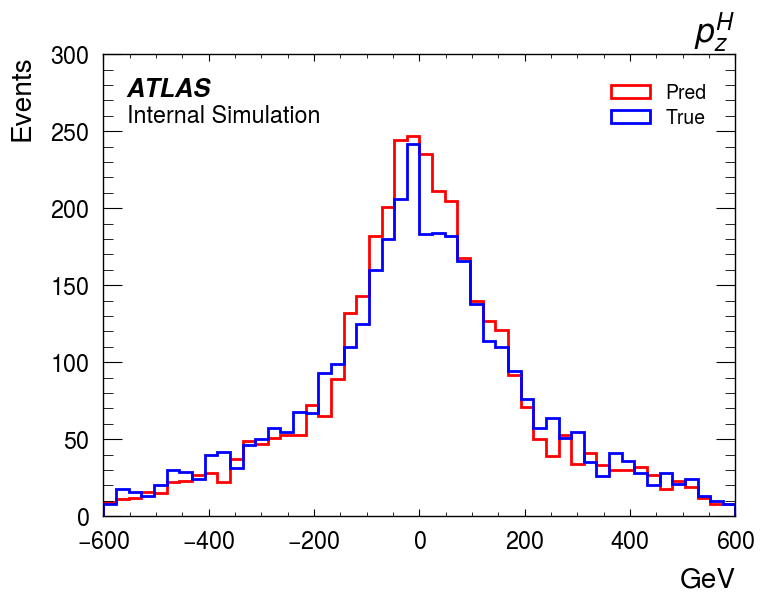

Rel err < 20%: 32.24 %


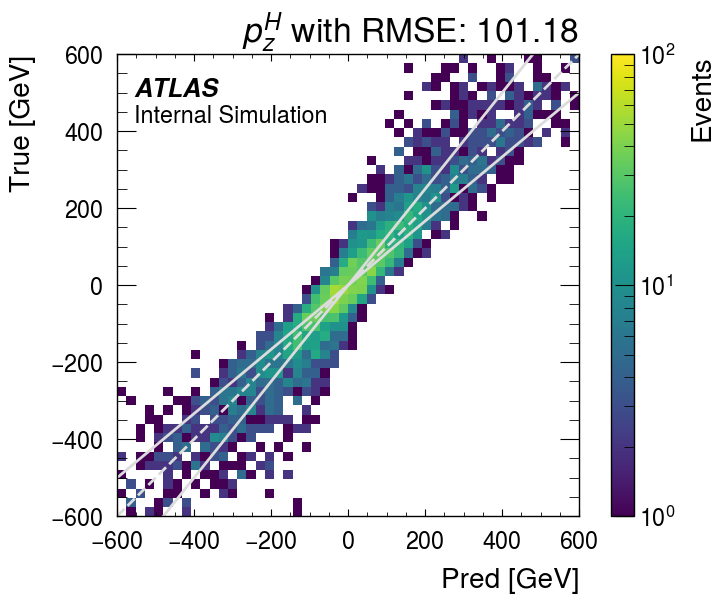

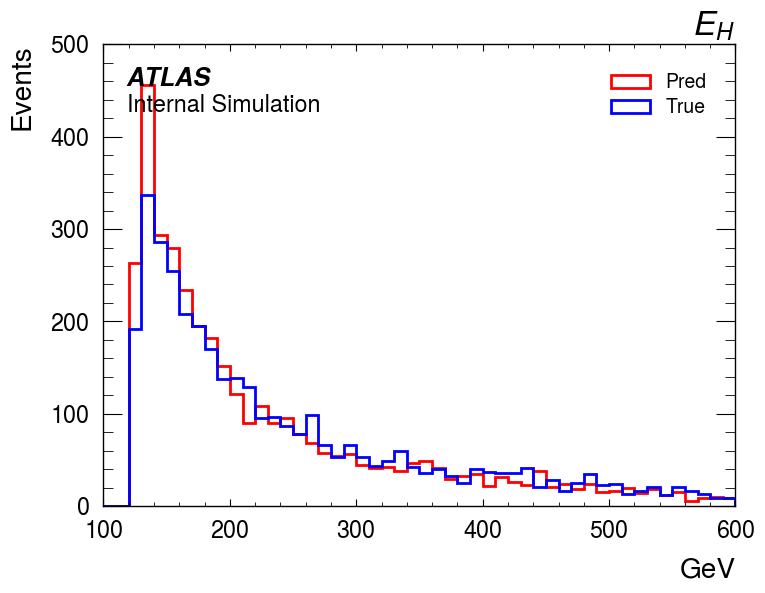

Rel err < 20%: 75.22 %


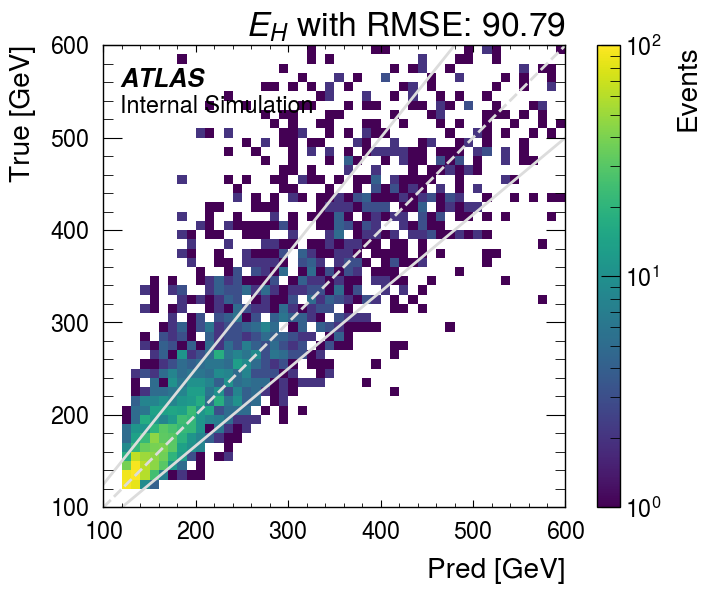

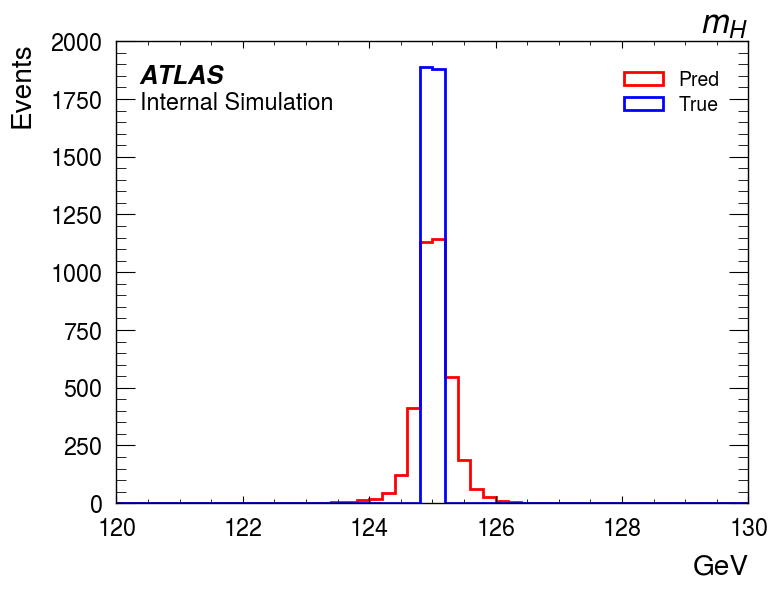

Rel err < 20%: 99.95 %


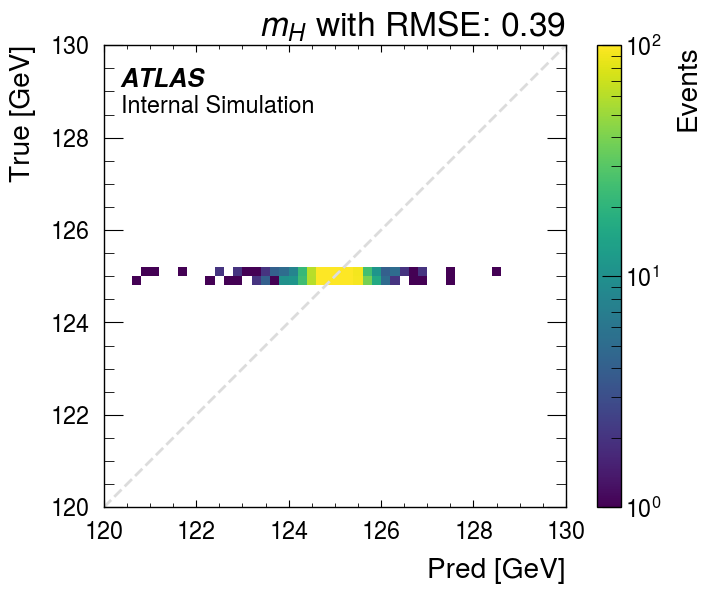

In [10]:
pred_higgs_px = pred_w0_px + pred_w1_px
pred_higgs_py = pred_w0_py + pred_w1_py
pred_higgs_pz = pred_w0_pz + pred_w1_pz
pred_higgs_energy = pred_w0_energy + pred_w1_energy
pred_higgs_mass = np.sqrt(pred_higgs_energy**2 - (pred_higgs_px**2 + pred_higgs_py**2 + pred_higgs_pz**2))
true_higgs_px = true_w0_px + true_w1_px
true_higgs_py = true_w0_py + true_w1_py
true_higgs_pz = true_w0_pz + true_w1_pz
true_higgs_energy = true_w0_energy + true_w1_energy
true_higgs_mass = np.sqrt(true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2))


plot_1d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), unit="GeV")
plot_2d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), log=True, unit="GeV")

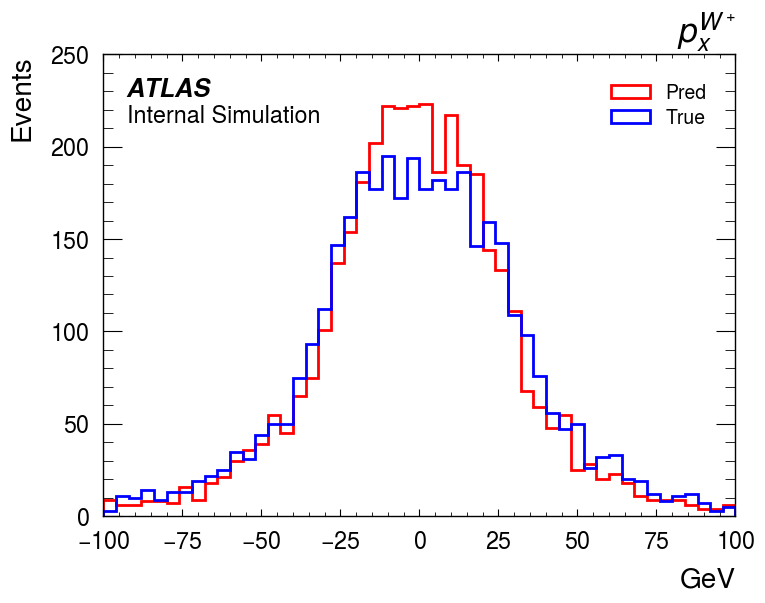

Rel err < 20%: 27.20 %


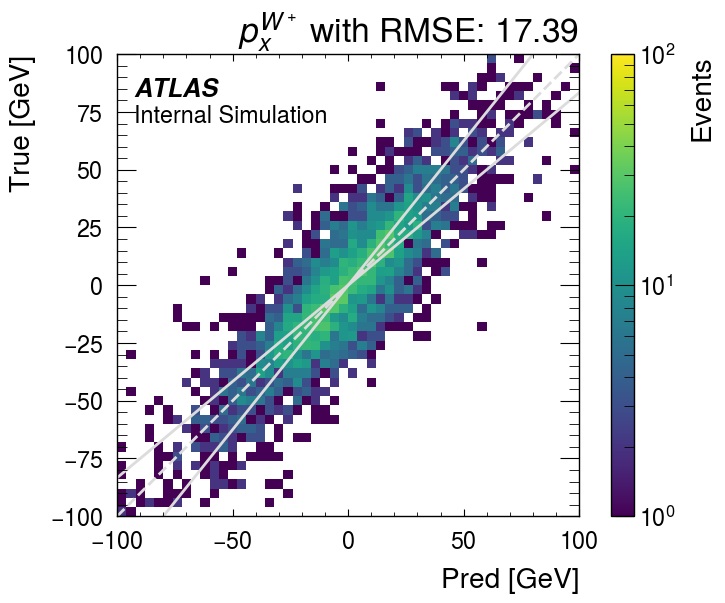

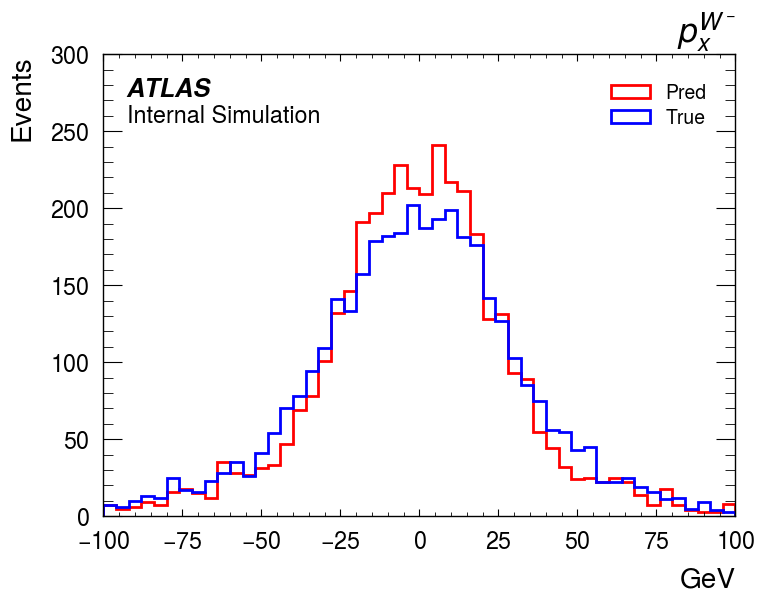

Rel err < 20%: 24.30 %


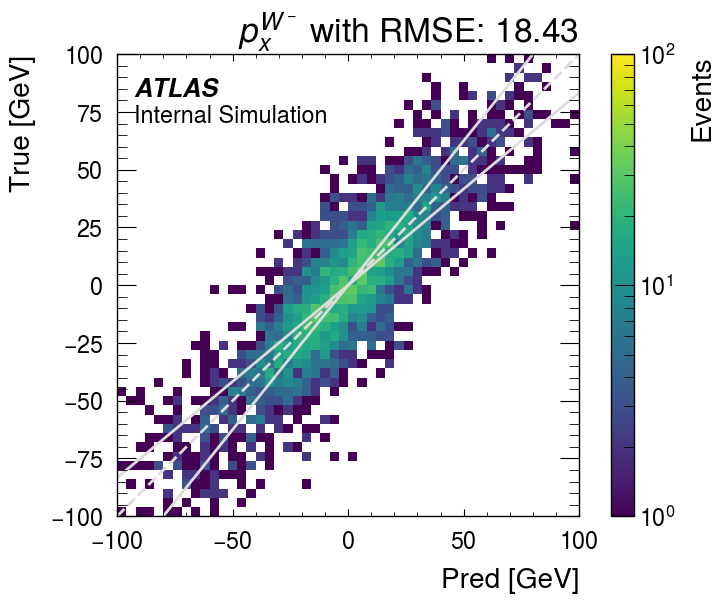

In [11]:
bins = np.linspace(-100, 100, 51)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True)

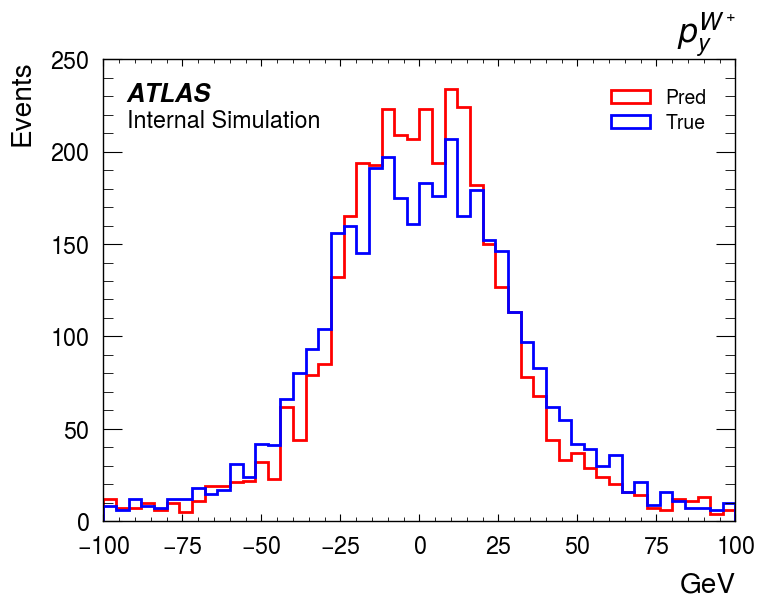

Rel err < 20%: 25.68 %


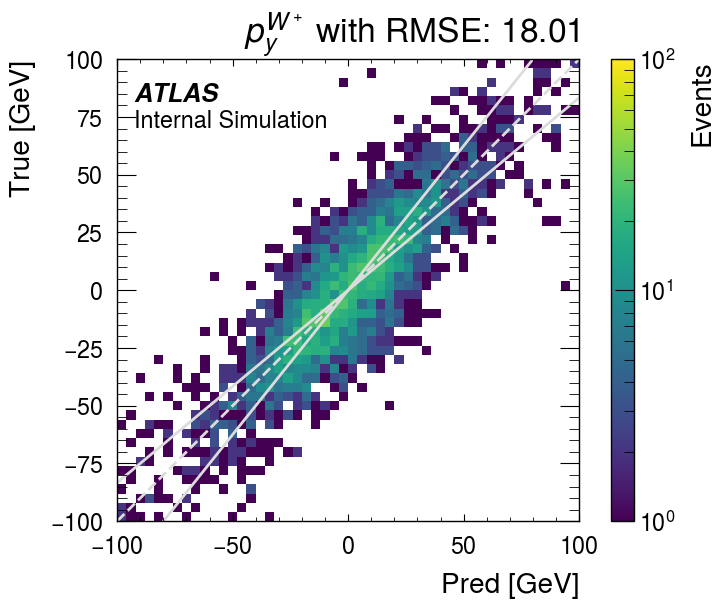

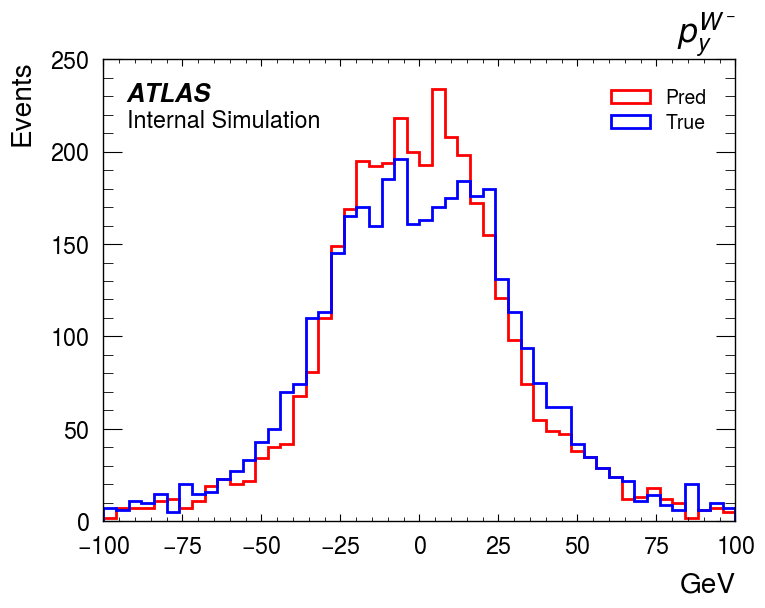

Rel err < 20%: 27.01 %


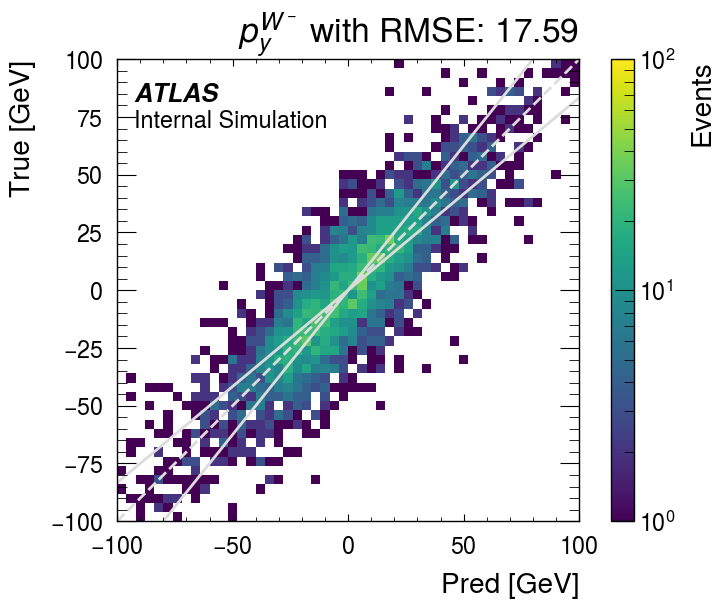

In [12]:
bins = np.linspace(-100, 100, 51)
plot_1d_hist(pred_w0_py, true_w0_py, bins_edges=bins, name=r"$p_y^{W^+}$")
plot_2d_hist(pred_w0_py, true_w0_py, name=r"$p_y^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_py, true_w1_py, bins_edges=bins, name=r"$p_y^{W^-}$")
plot_2d_hist(pred_w1_py, true_w1_py, name=r"$p_y^{W^-}$", bins_edges=bins, log=True)

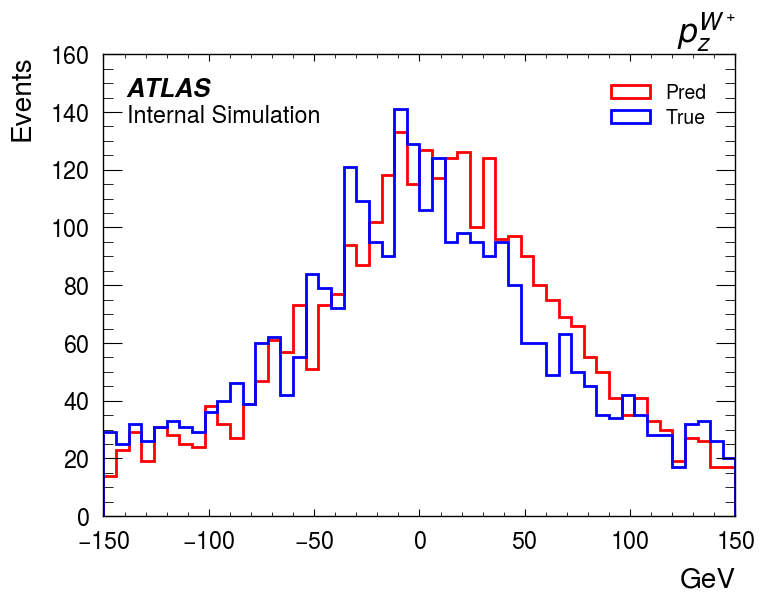

Rel err < 20%: 28.68 %


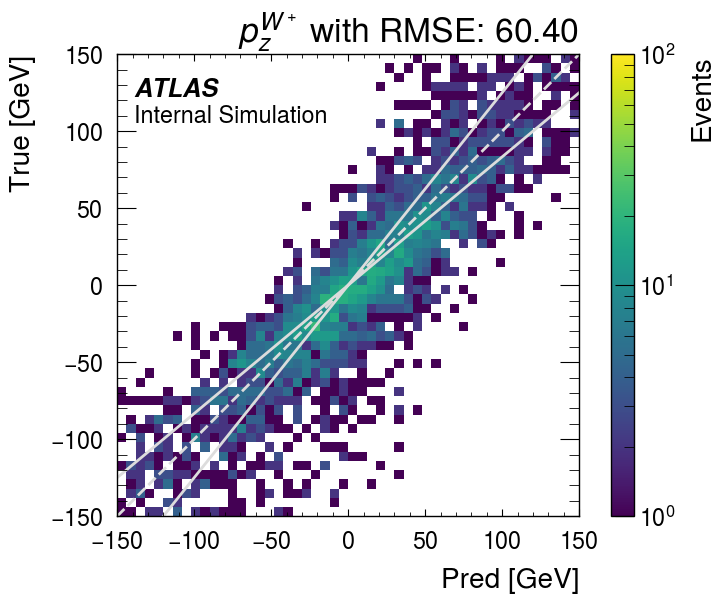

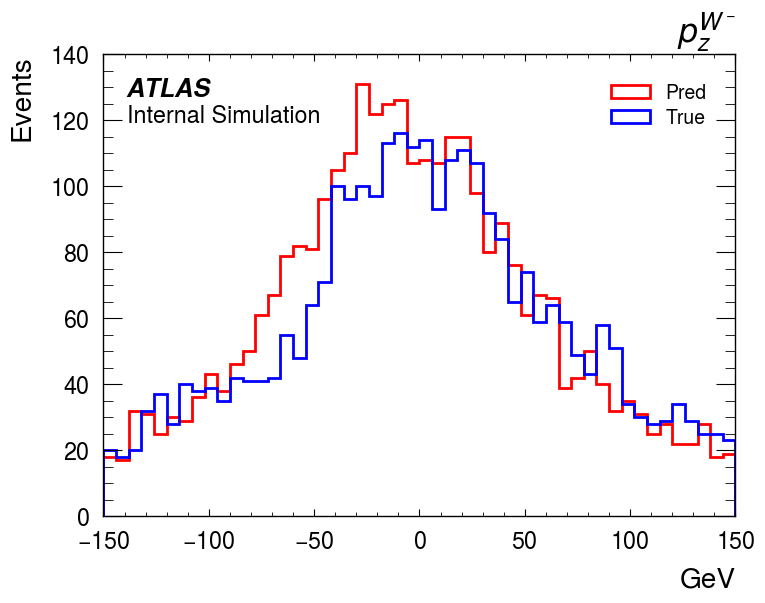

Rel err < 20%: 29.32 %


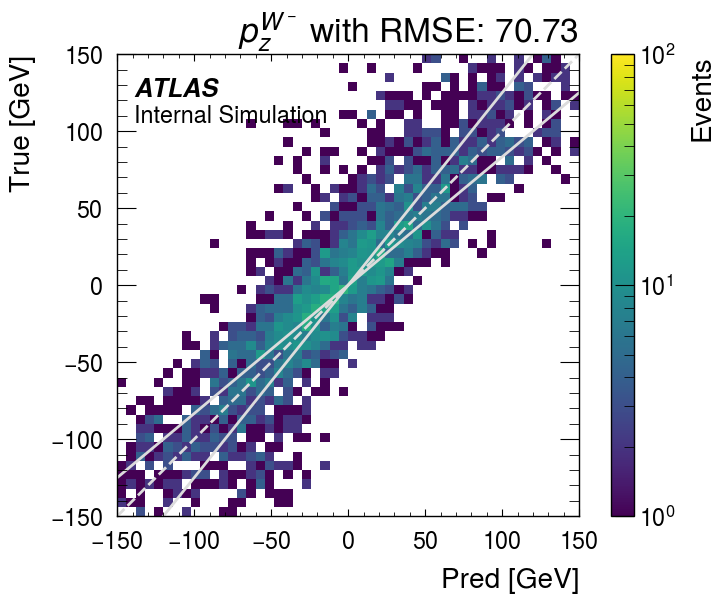

In [13]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True)

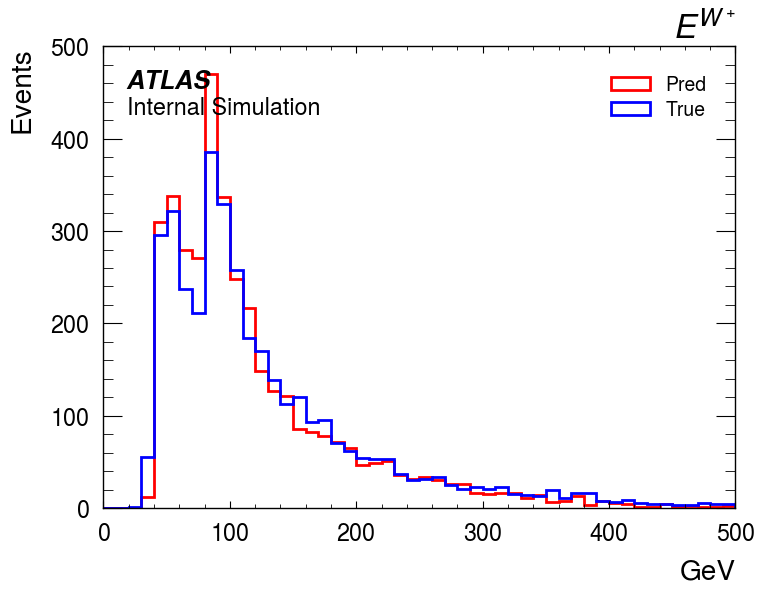

Rel err < 20%: 60.18 %


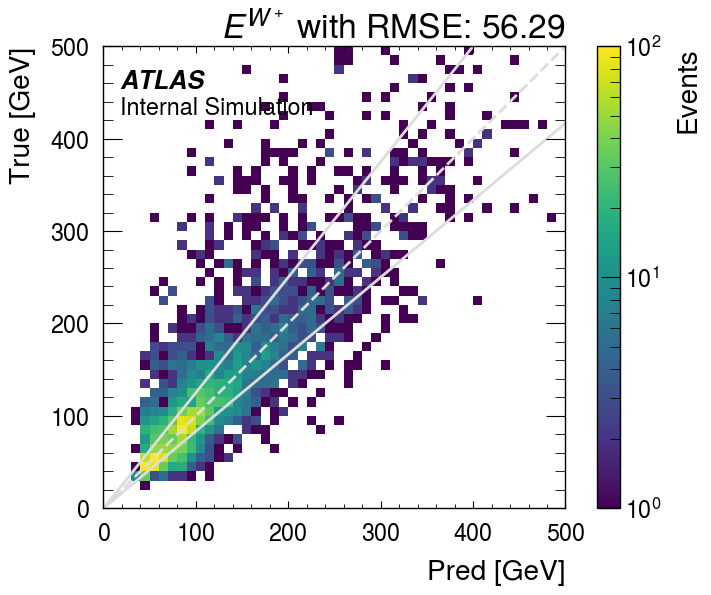

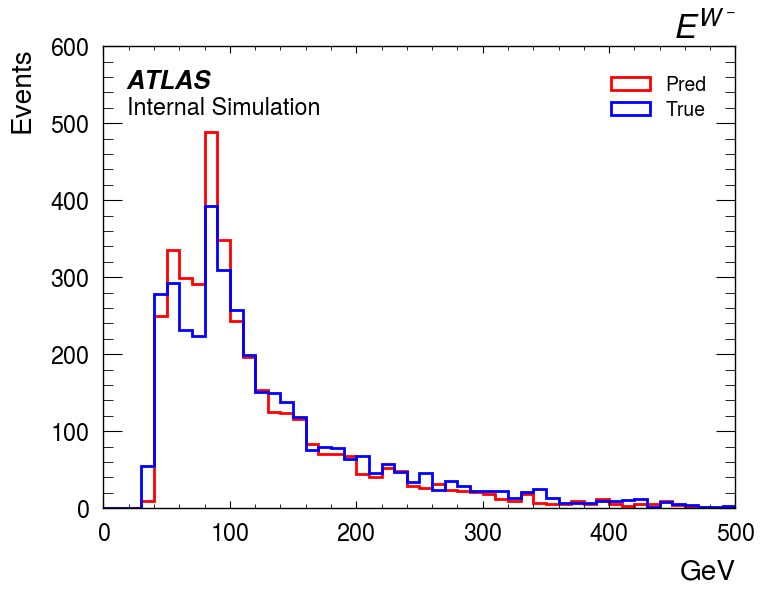

Rel err < 20%: 59.62 %


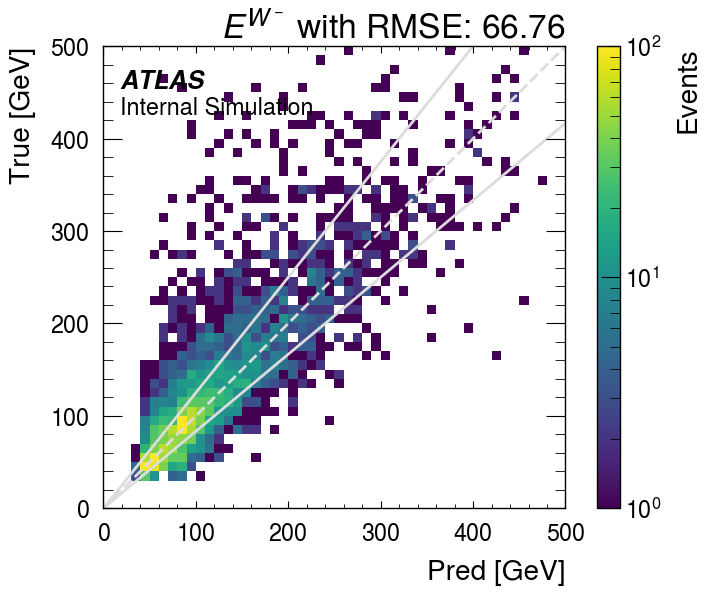

In [14]:
bins = np.linspace(0, 500, 51)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black")
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black")

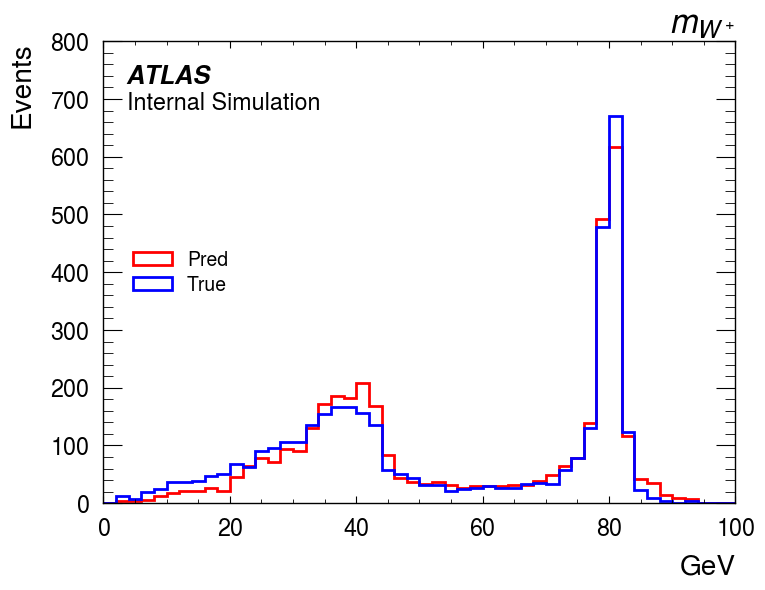

Rel err < 20%: 56.59 %


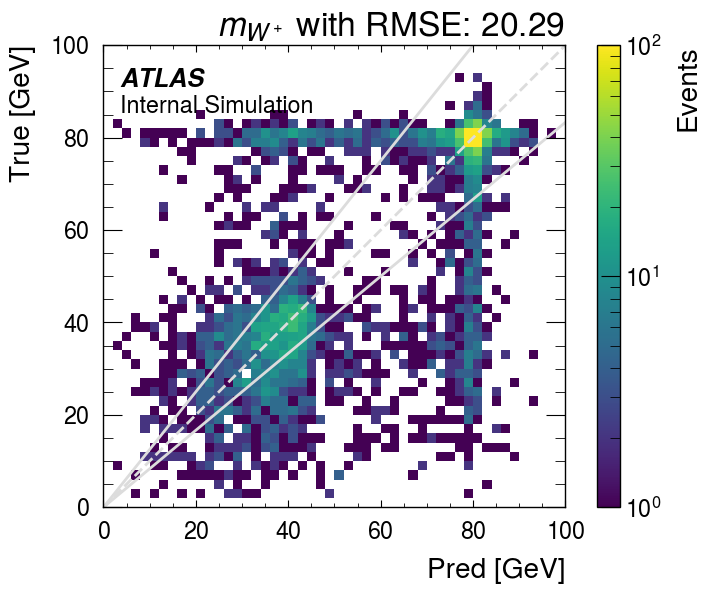

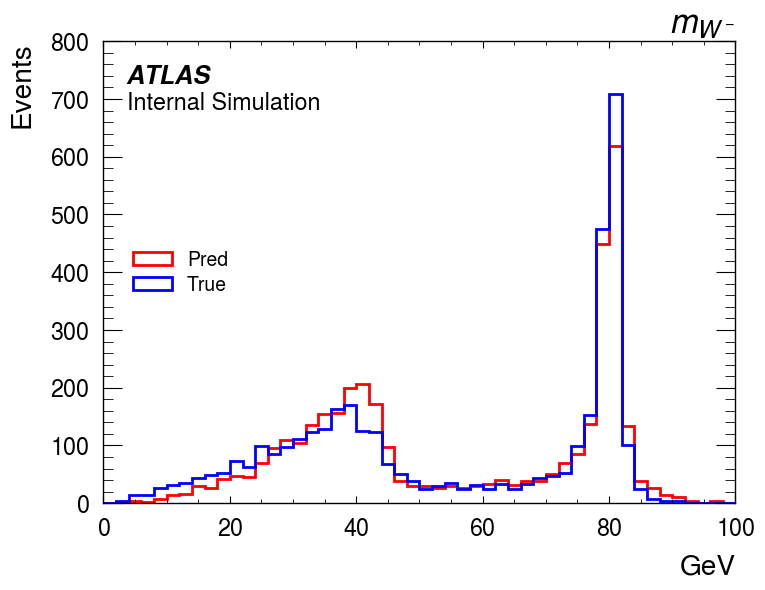

Rel err < 20%: 56.38 %


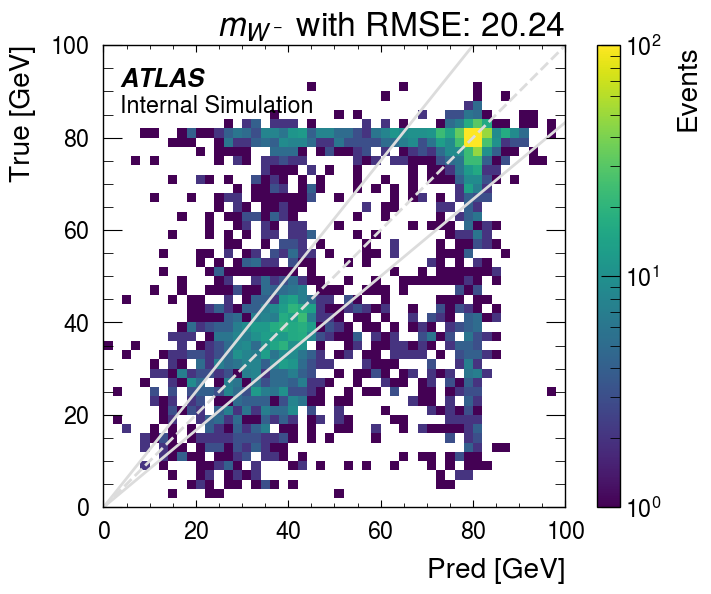

In [15]:
bins = np.linspace(0, 100, 51)
plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV")

In [16]:
def plot_2d_res_hist(pred, truth, name_pos, name_neg, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(rf"$\Delta_\text{{res}}${name_pos} [{unit}]")
    plt.ylabel(rf"$\Delta_\text{{res}}${name_neg} [{unit}]")
    # plt.title(rf"{title}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=0, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

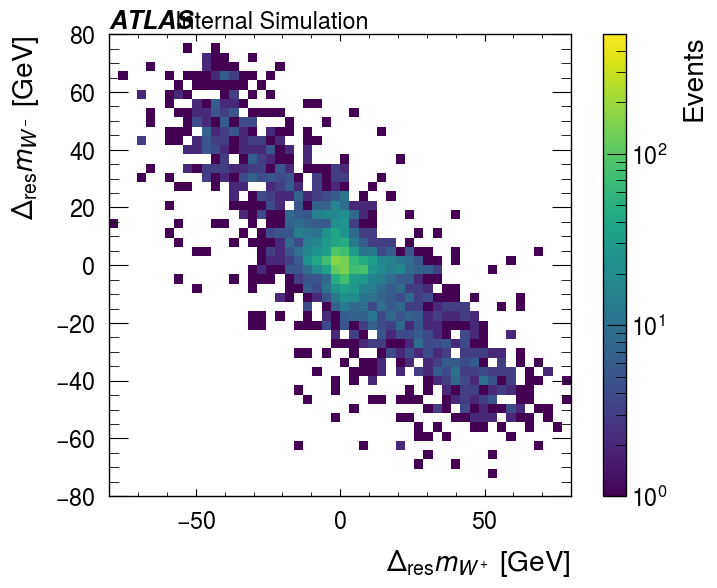

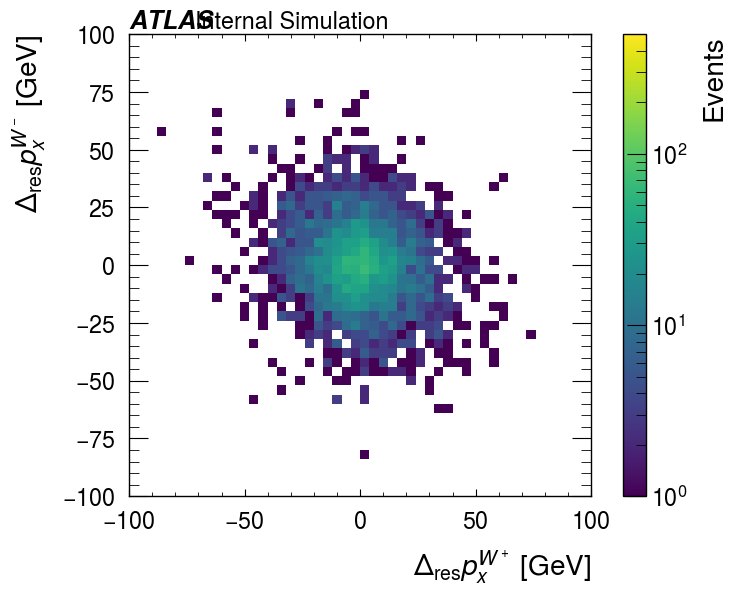

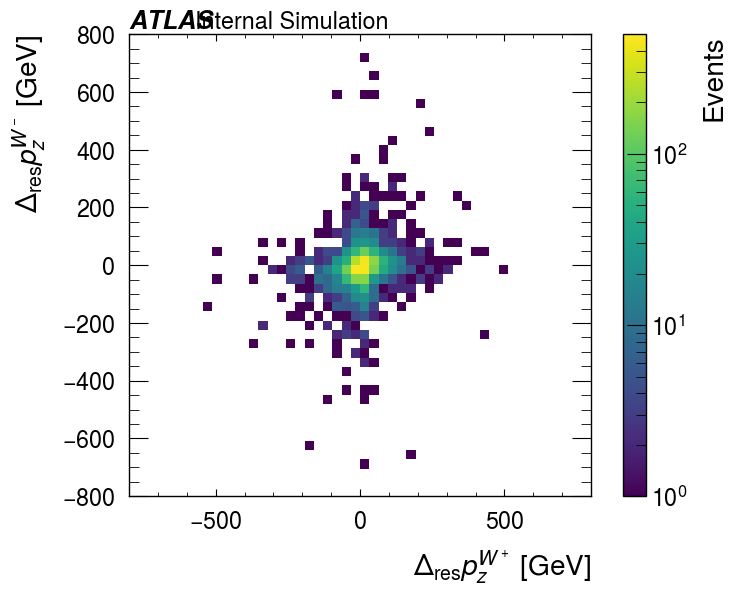

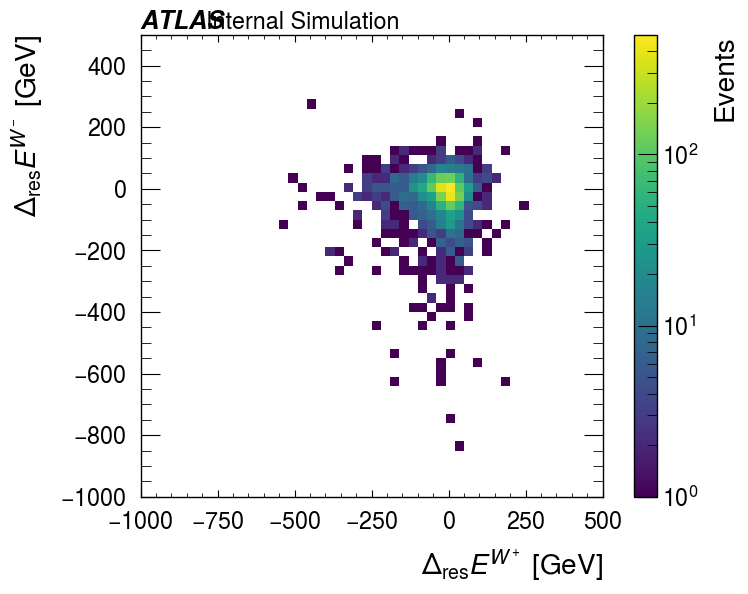

In [17]:
w0_mass_res = np.sqrt(pred_w0_mass_2) - np.sqrt(true_w0_mass_2)
w1_res = np.sqrt(pred_w1_mass_2) - np.sqrt(true_w1_mass_2)
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 51), log=True, unit="GeV", color="black", vmax=5e2)

In [18]:

def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

# true
true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=-1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=-1)
true_lep0_p4 = np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=-1)
true_lep1_p4 = np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=-1)

# pred
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=-1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=-1)

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2

true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_lep_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep0_p4, true_lep1_p4)
true_lep_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep1_p4, true_lep0_p4)
true_w_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w0_p4, true_w1_p4)
true_w_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w_off_p4 - true_lep_off_p4

pred_0_on_mask = np.abs(pred_w0_mass_2 - w_mass_con_2) < np.abs(pred_w1_mass_2 - w_mass_con_2)
pred_w_on_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w0_p4, pred_w1_p4)
pred_w_off_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w1_p4, pred_w0_p4)
pred_neu_on_p4 = pred_w_on_p4 - true_lep_on_p4
pred_neu_off_p4 = pred_w_off_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

/tmp/ipykernel_244313/2923680903.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)


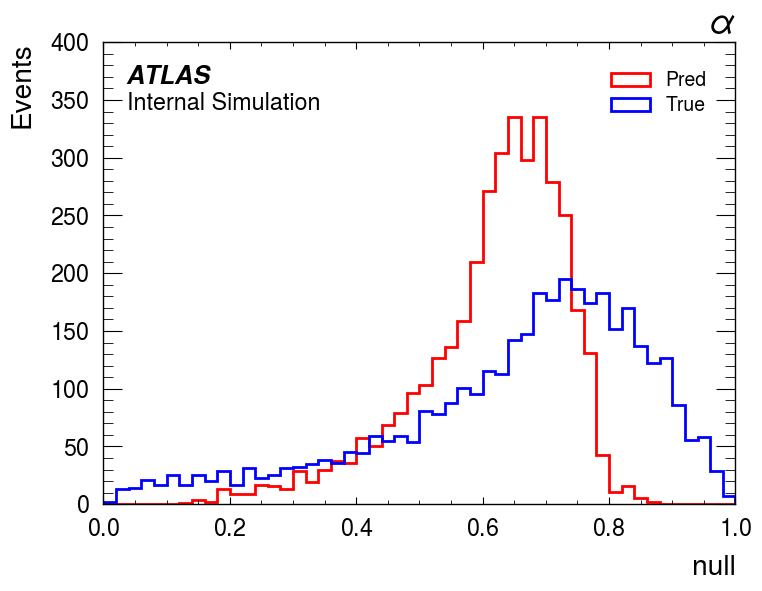

l+ alpha RMSE: 0.21747115930136235
Rel err < 20%: 50.92 %


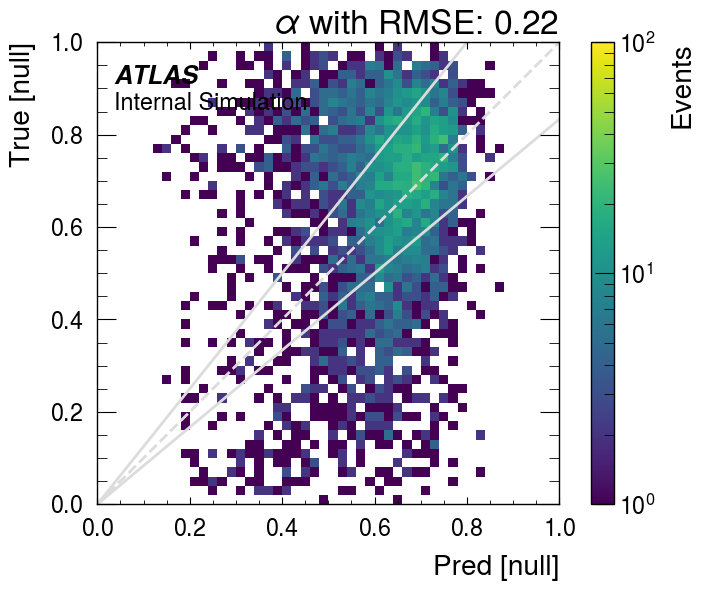

In [19]:
plot_1d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null")
print("l+ alpha RMSE:", rmse(pred_alpha, true_alpha))
plot_2d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), log=True, unit="null", color="black", vmax=1e2)

In [20]:
from ohbboosting import Booster

true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=1)
true_l0_p4 = np.stack([true_lep0_px,true_lep0_py,true_lep0_pz,true_lep0_energy], axis=1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=1)
true_l1_p4 = np.stack([true_lep1_px,true_lep1_py,true_lep1_pz,true_lep1_energy], axis=1)

particles = np.concatenate(
	[
		true_w0_p4,
		true_l0_p4,
		true_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# true_xi_pos, true_xi_neg = booster.lep_xi_in_w_rest()
# true_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!


/opt/conda/envs/torch/lib/python3.11/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /opt/conda/envs/torch/include/site/python3.11); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


Booster setup completed.
(3769, 16)


In [21]:
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi, pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(3769, 16)


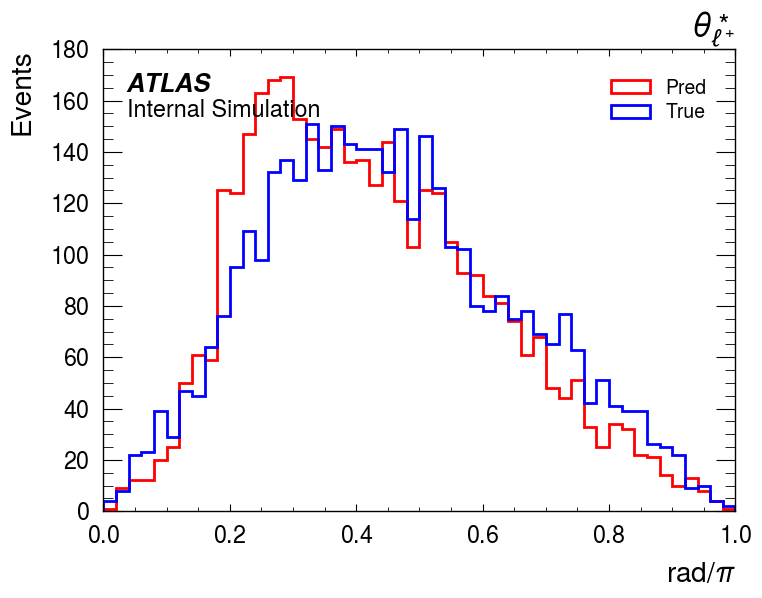

l+ theta RMSE: 0.21569922646523304
Rel err < 20%: 39.03 %


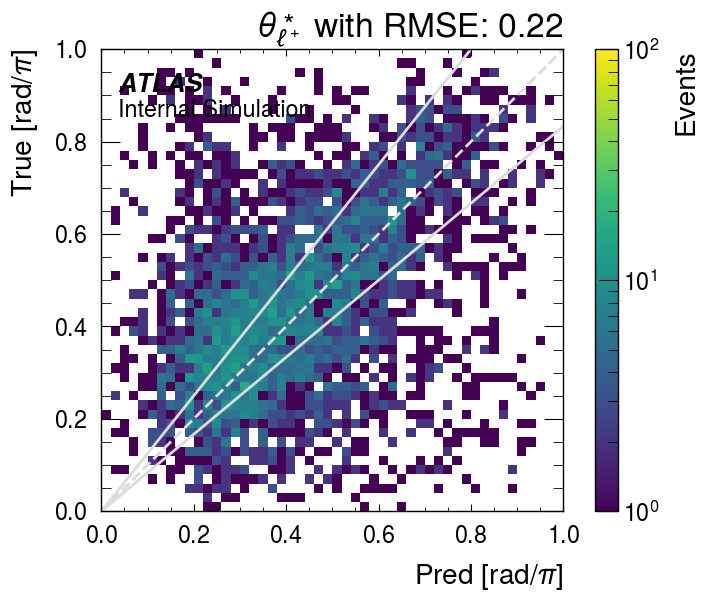

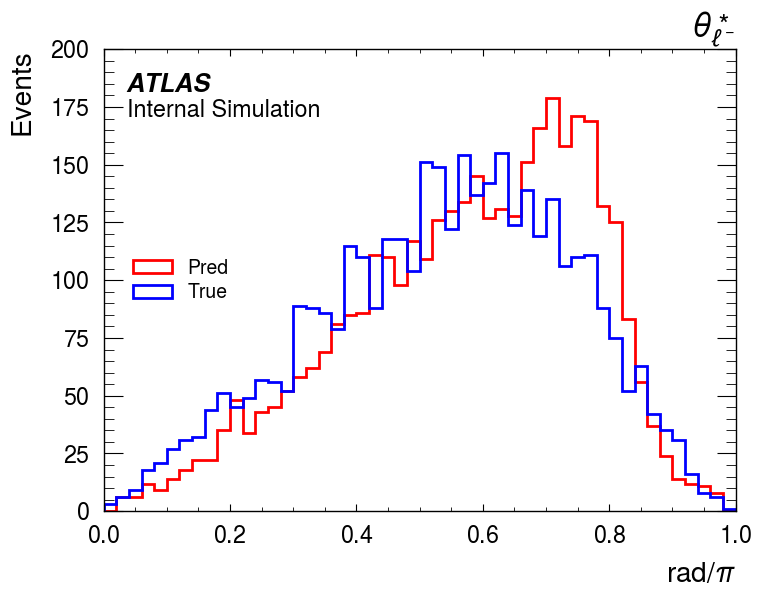

l_ theta RMSE: 0.21546263295517015
Rel err < 20%: 48.34 %


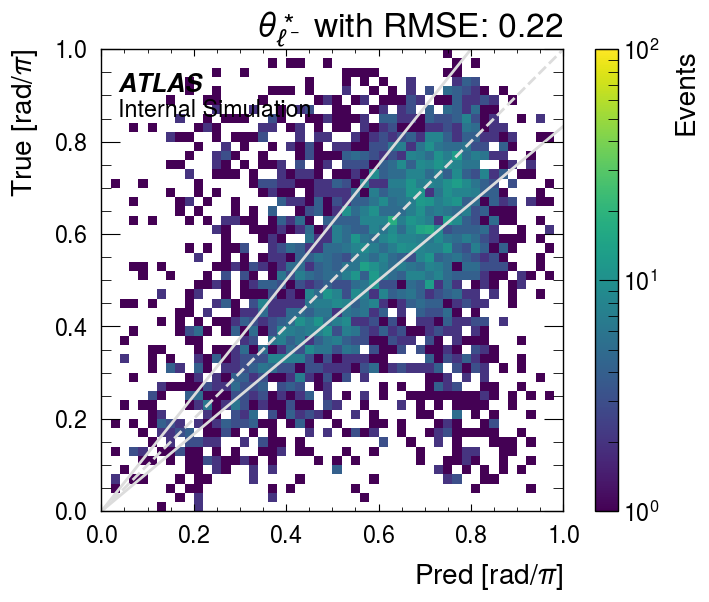

In [22]:
plot_1d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l+ theta RMSE:", rmse(pred_l0_theta_phi[0], true_l0_theta_phi[0]))
plot_2d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l_ theta RMSE:", rmse(pred_l1_theta_phi[0], true_l1_theta_phi[0]))
plot_2d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

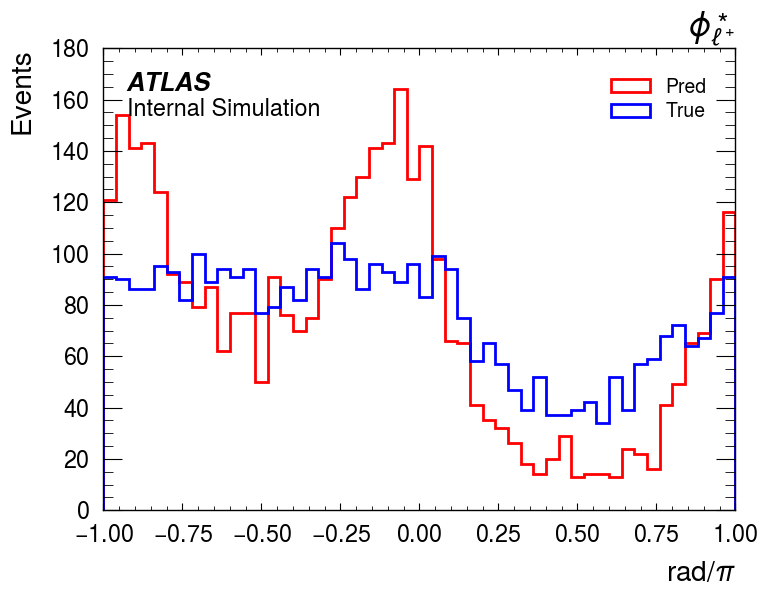

l+ phi RMSE: 0.7396367990792957
Rel err < 20%: 18.52 %


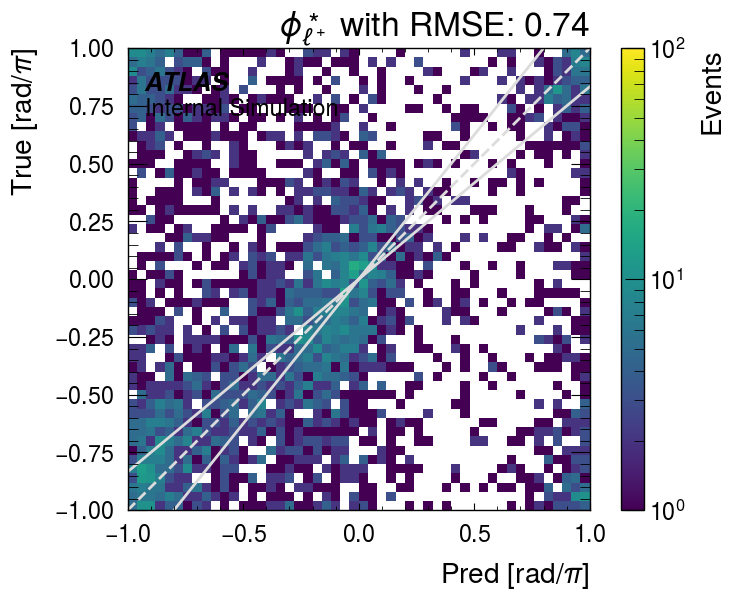

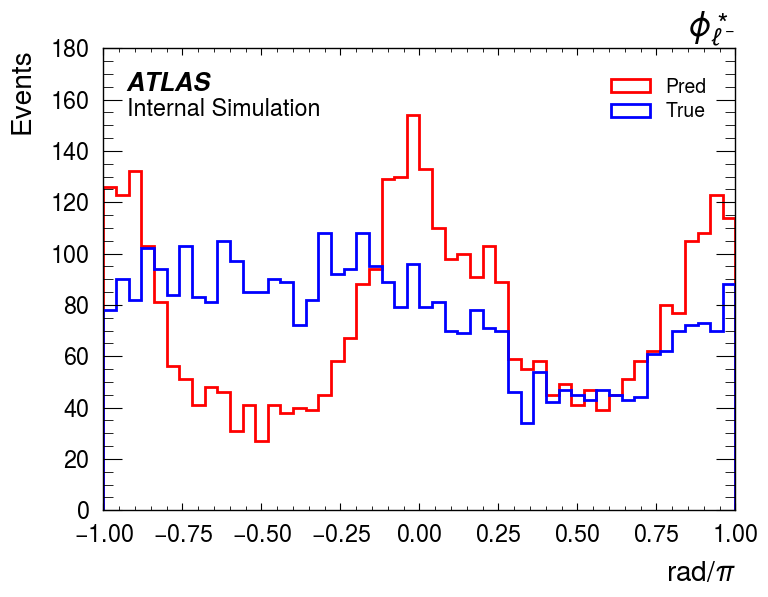

l- phi RMSE: 0.7490362945321886
Rel err < 20%: 19.32 %


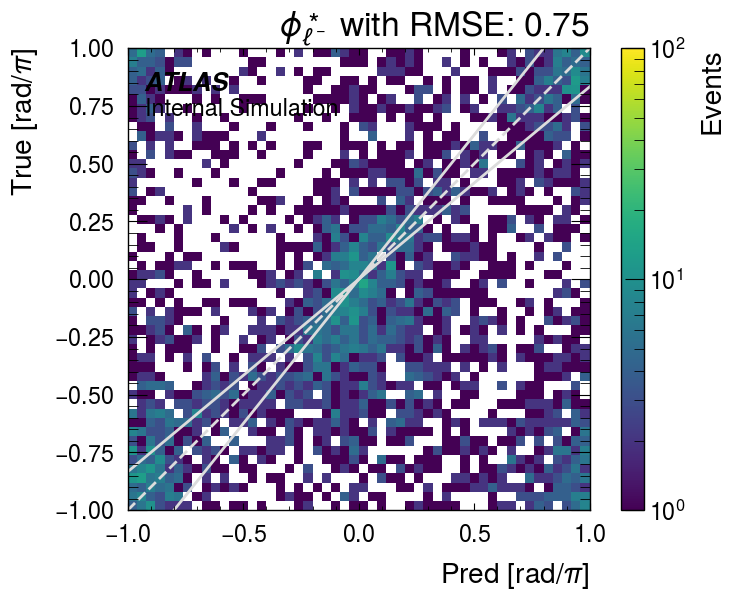

In [23]:
plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l+ phi RMSE:", rmse(pred_l0_theta_phi[1], true_l0_theta_phi[1]))
plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l- phi RMSE:", rmse(pred_l1_theta_phi[1], true_l1_theta_phi[1]))
plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

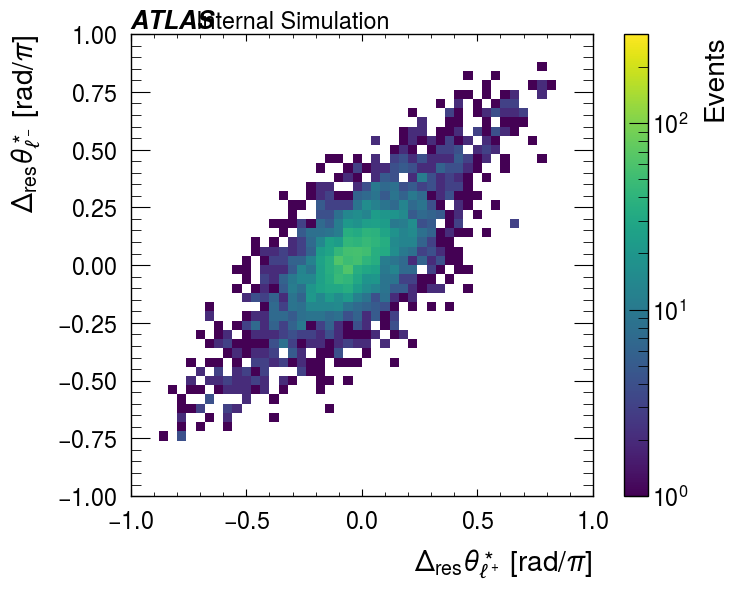

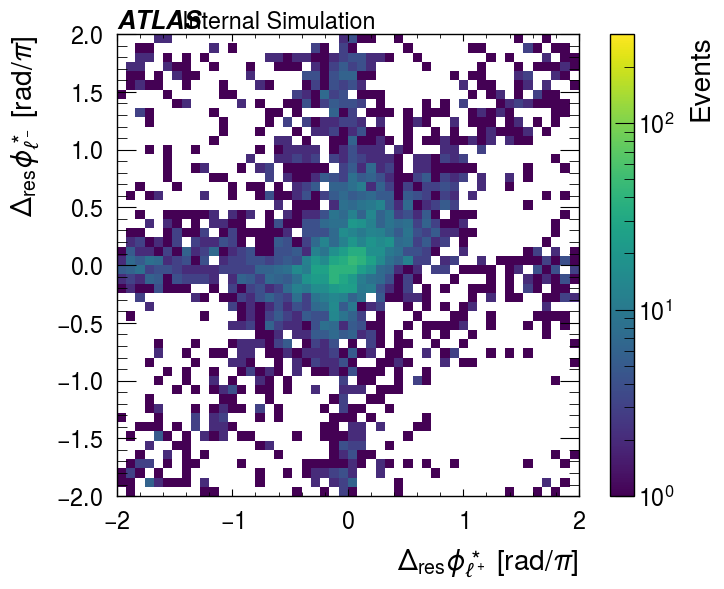

In [24]:
l0_theta_res = pred_l0_theta_phi[0] - true_l0_theta_phi[0]
l1_theta_res = pred_l1_theta_phi[0] - true_l1_theta_phi[0]
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

l0_phi_res = pred_l0_theta_phi[1] - true_l0_theta_phi[1]
l1_phi_res = pred_l1_theta_phi[1] - true_l1_theta_phi[1]
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

In [25]:
def dphi(phi1, phi2):
    phi_diff = phi1 * np.pi - phi2 * np.pi
    phi_diff = np.where(phi_diff < 0.0, -phi_diff, phi_diff)
    phi_diff = np.where(phi_diff > 2.0 * np.pi, phi_diff - 2.0 * np.pi, phi_diff)
    phi_diff = np.where(phi_diff >= np.pi, 2.0 * np.pi - phi_diff, phi_diff)
    return np.divide(phi_diff, np.pi)

def dtheta(theta1, theta2):
	theta_diff = theta1 * np.pi - theta2 * np.pi
	theta_diff = np.where(theta_diff < 0.0, -theta_diff, theta_diff)
	theta_diff = np.where(theta_diff > np.pi, theta_diff - np.pi, theta_diff)
	return np.divide(theta_diff, np.pi)

In [26]:
def plot_1d_true_pred_diff(diff, name, bins_edges=np.linspace(-1, 1, 51), unit="rad/$\pi$", color="black", savepath=None):
	plt.hist(diff, bins=bins_edges, linewidth=2, color="green", histtype="step", label=name)
	plt.legend()
	plt.xlabel(f"{name} [{unit}]", loc="right")
	plt.ylabel("Events", loc="top")
	# plt.title(name, loc="right")
	
	txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
	txt[0].set_color(color)
	txt[1].set_color(color)
	plt.tick_params(axis="both", which="major", pad=10)
	if savepath is not None:
		plt.savefig(savepath, bbox_inches="tight")
	plt.show()

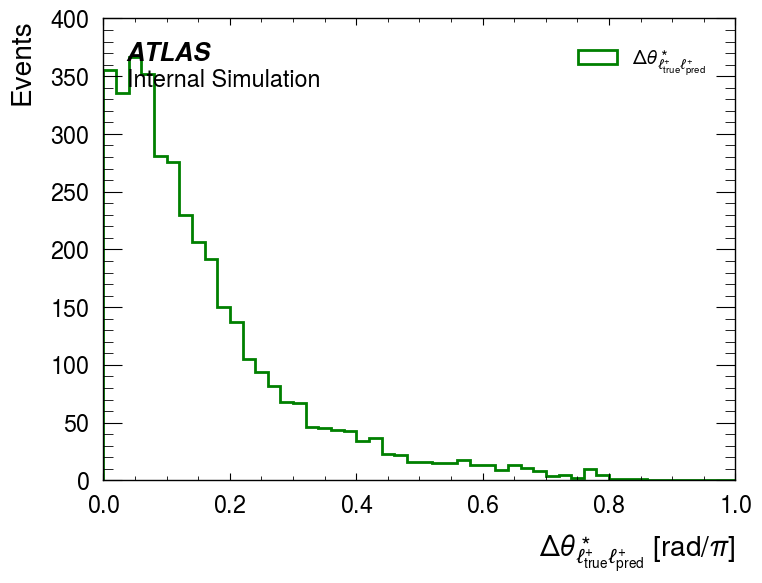

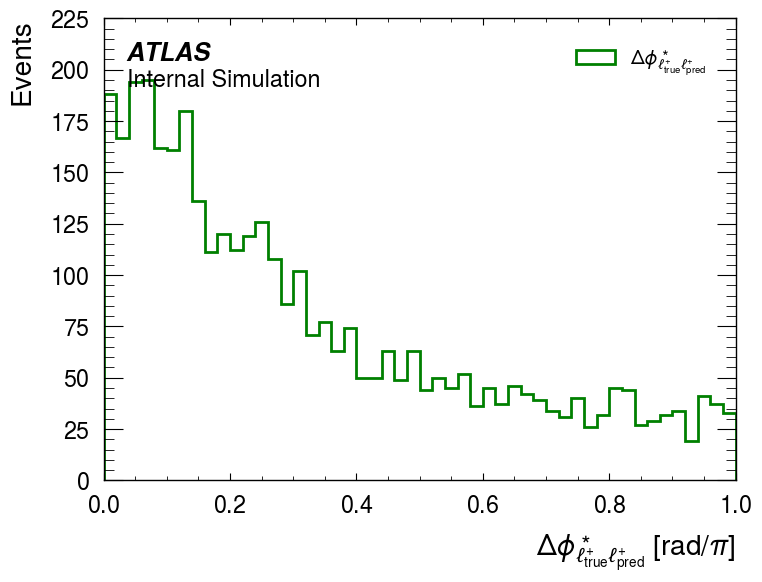

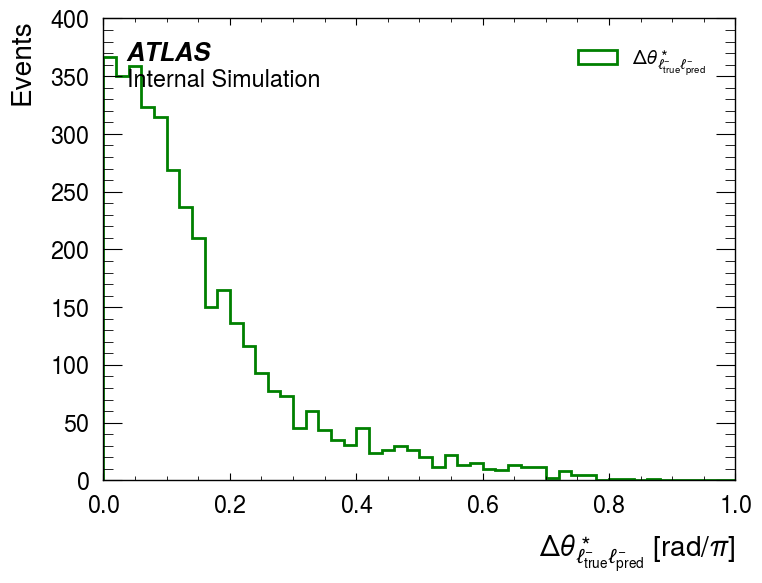

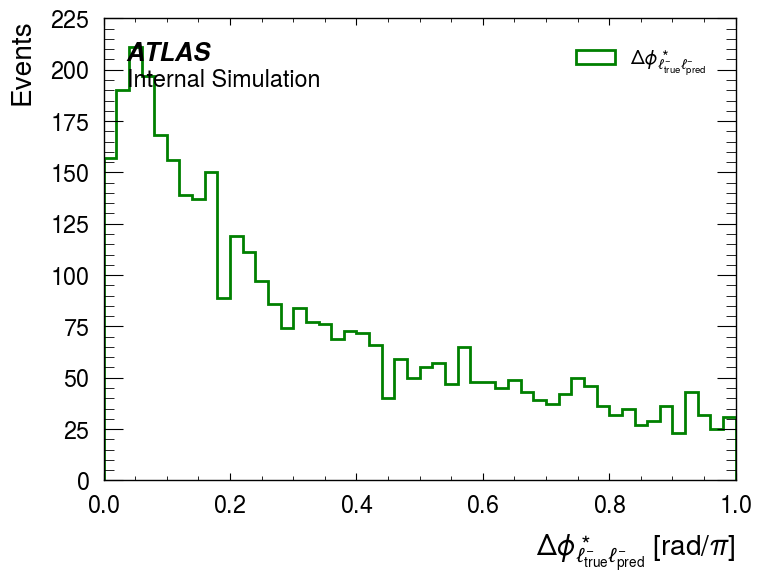

In [27]:
dtheta_pos = dtheta(pred_l0_theta_phi[0], true_l0_theta_phi[0])
dphi_pos = dphi(pred_l0_theta_phi[1], true_l0_theta_phi[1])
dtheta_neg = dtheta(pred_l1_theta_phi[0], true_l1_theta_phi[0])
dphi_neg = dphi(pred_l1_theta_phi[1], true_l1_theta_phi[1])

plot_1d_true_pred_diff(dtheta_pos, r"$\Delta \theta_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dphi_pos, r"$\Delta \phi_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dtheta_neg, r"$\Delta \theta_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dphi_neg, r"$\Delta \phi_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")

Found log directories: ['./hww_pcres_regressor_nofold/logs/version_0/']


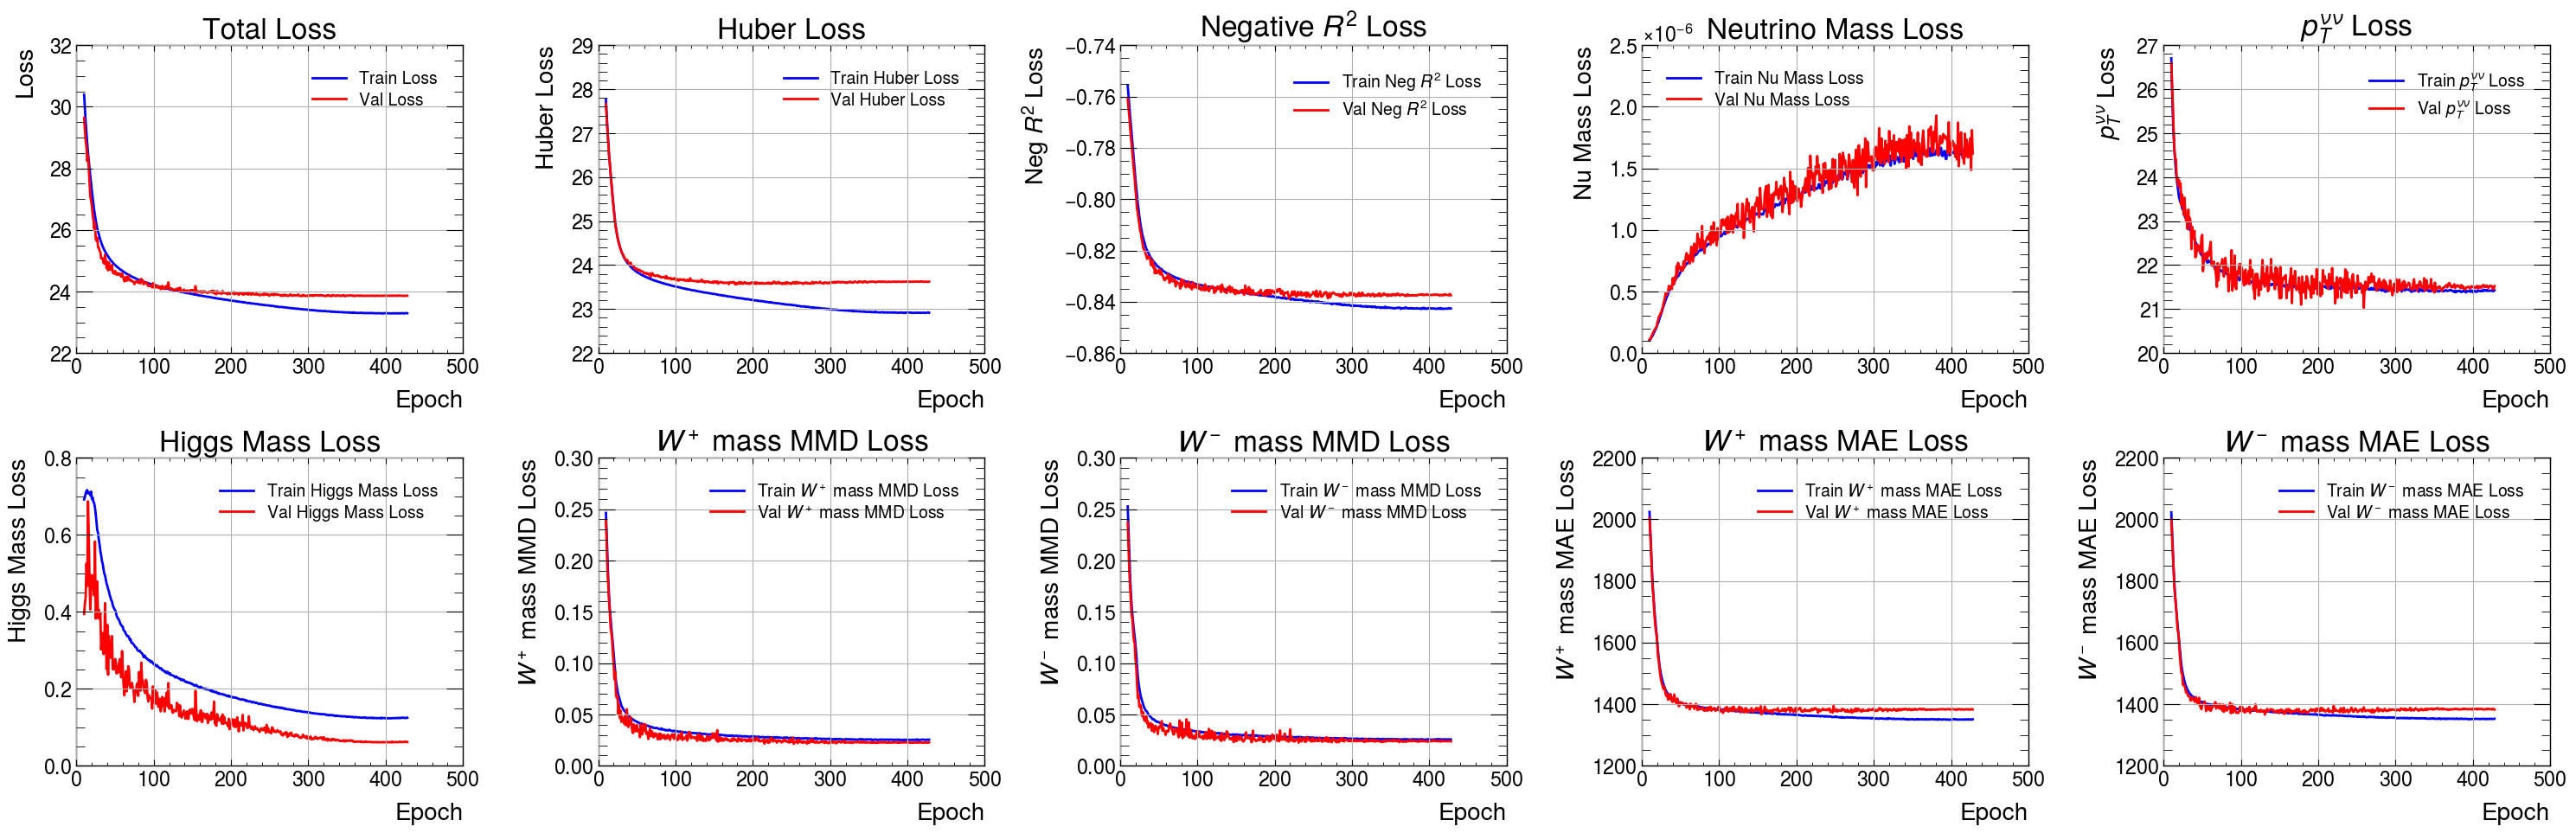

Final Training Losses (Epoch 428):
  Total Loss: 23.293493
  Huber Loss: 22.916769
  Negative $R^2$ Loss: -0.842629
  Neutrino Mass Loss: 0.000002
  $p^{\nu\nu}_T$ Loss: 21.424026
  Higgs Mass Loss: 0.124672
  $W^+$ mass MMD Loss: 0.025385
  $W^-$ mass MMD Loss: 0.025570
  $W^+$ mass MAE Loss: 1350.813354
  $W^-$ mass MAE Loss: 1352.586060
  $W^+$ mom MMD Loss: 0.016474
  $W^-$ mom MMD Loss: 0.016295
Final Validation Losses:
  Total Loss: 23.864529
  Huber Loss: 23.624660
  Negative $R^2$ Loss: -0.837504
  Neutrino Mass Loss: 0.000002
  $p^{\nu\nu}_T$ Loss: 21.522421
  Higgs Mass Loss: 0.061760
  $W^+$ mass MMD Loss: 0.022833
  $W^-$ mass MMD Loss: 0.023706
  $W^+$ mass MAE Loss: 1382.719727
  $W^-$ mass MAE Loss: 1382.582397
  $W^+$ mom MMD Loss: 0.016703
  $W^-$ mom MMD Loss: 0.016172


In [28]:
log_dirs = glob.glob(f"./hww_pcres_regressor_nofold/logs/version_0/")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 10))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("huber_loss", "val_huber_loss", "Huber Loss", "Huber Loss"),
                ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W^+$ mass MMD Loss", "$W^+$ mass MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W^-$ mass MMD Loss", "$W^-$ mass MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W^+$ mass MAE Loss", "$W^+$ mass MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W^-$ mass MAE Loss", "$W^-$ mass MAE Loss"),
                ("aux_mom_mmd0_loss", "val_aux_mom_mmd0_loss", "$W^+$ mom MMD Loss", "$W^+$ mom MMD Loss"),
                ("aux_mom_mmd1_loss", "val_aux_mom_mmd1_loss", "$W^-$ mom MMD Loss", "$W^-$ mom MMD Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[10:]
            epochs_val = df_clean_val["epoch"].iloc[10:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[10:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[10:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                # apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"Final Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("Final Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")

In [29]:
# import shap
# import matplotlib as mpl

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Use GradientExplainer with separate background and test samples
# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# for i in range(shap_values.shape[-1]):
# 	fig = plt.figure(figsize=(10, 8))
# 	shap.summary_plot(
# 		shap_values[:, :, i],
# 		samples_to_explain.cpu().numpy(),
# 		# No feature_names - will use feature indices 0-71
# 		plot_type="dot",
# 		max_display=10,
# 		show=False,
# 	)
# 	plt.title(f"SHAP Summary Plot for Output {i}", fontsize=16)
# 	plt.tight_layout()
# 	plt.show()

In [30]:
pred_nu0_p4 = pred_w0_p4 - true_lep0_p4
pred_nu1_p4 = pred_w1_p4 - true_lep1_p4
swap_pred_nu0_p4 = pred_w0_p4 - true_lep1_p4
swap_pred_nu1_p4 = pred_w1_p4 - true_lep0_p4
pred_met = np.sqrt(
    (pred_nu0_p4[:, 0] + pred_nu1_p4[:, 0])**2 + 
    (pred_nu0_p4[:, 1] + pred_nu1_p4[:, 1])**2
)
swap_pred_met = np.sqrt(
    (swap_pred_nu0_p4[:, 0] + swap_pred_nu1_p4[:, 0])**2 + 
    (swap_pred_nu0_p4[:, 1] + swap_pred_nu1_p4[:, 1])**2
)
true_met = np.sqrt(true_met_px**2 + true_met_py**2)

def met_diff(pred_met, true_met):
    return np.abs(pred_met - true_met)

pred_met_diff = met_diff(pred_met, true_met)
swap_pred_met_diff = met_diff(swap_pred_met, true_met)
pred_correct = np.where(pred_met_diff > swap_pred_met_diff, True, False)


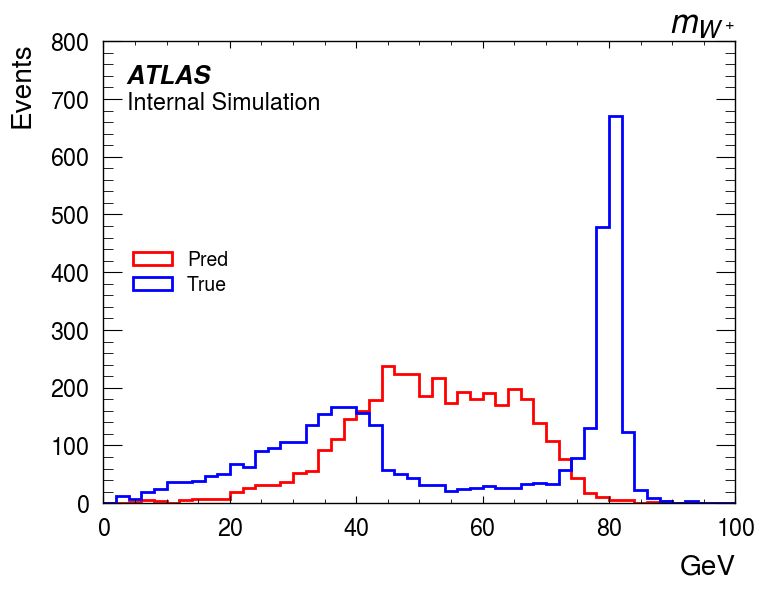

Rel err < 20%: 16.64 %


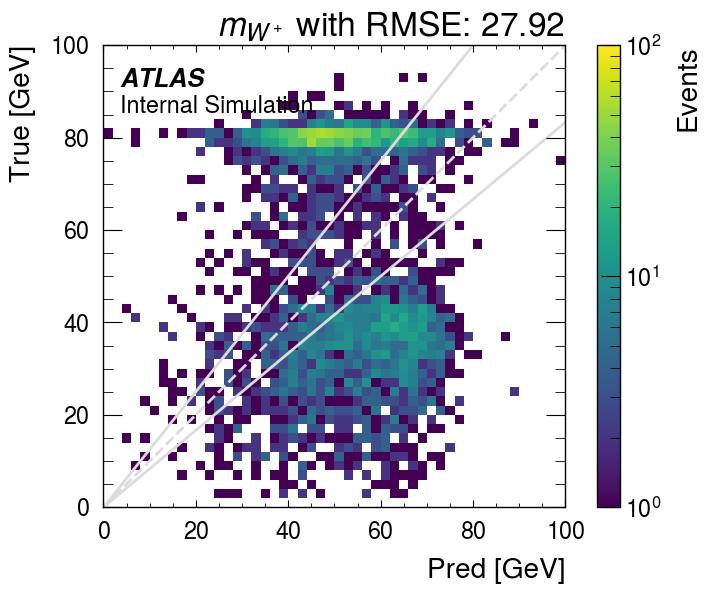

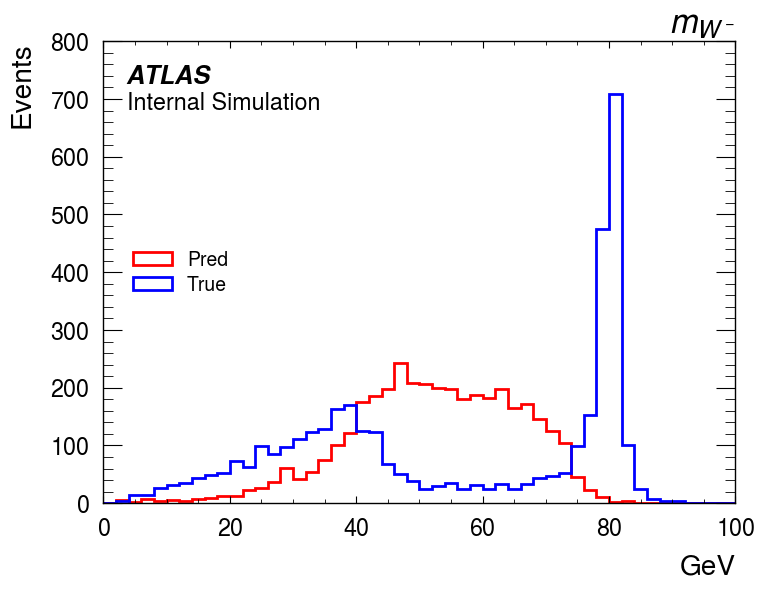

Rel err < 20%: 17.51 %


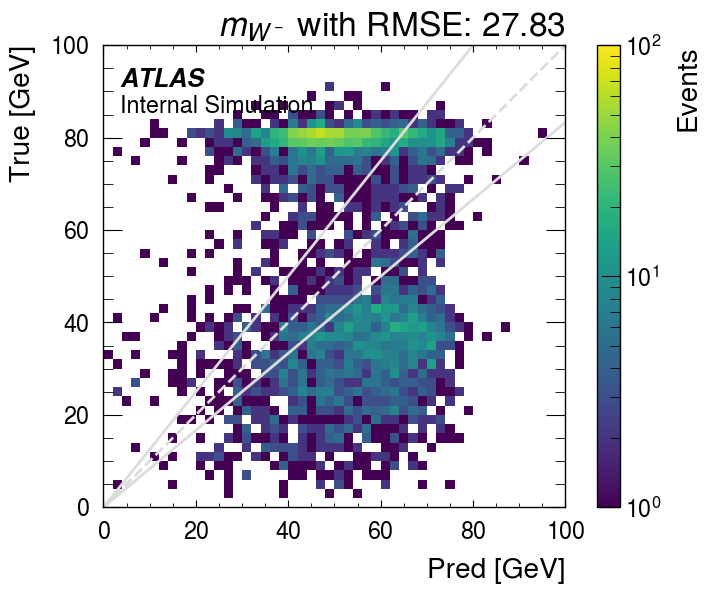

In [31]:
def replace_lep(w0_p4, w1_p4, lep0_p4, lep1_p4, mask):
    _neu_0_p4 = w0_p4 - lep0_p4
    _neu_1_p4 = w1_p4 - lep1_p4
    # If mask is True, swap the leptons
    new_w0_p4 = np.where(mask[:, None], w0_p4, _neu_1_p4 + lep0_p4)
    new_w1_p4 = np.where(mask[:, None], w1_p4, _neu_0_p4 + lep1_p4)
    return new_w0_p4, new_w1_p4

# swapeed w p4
swap_pred_w0_p4, swap_pred_w1_p4 = replace_lep(
    np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1),
    np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1),
    np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=1),
    np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=1),
    pred_correct
)

pred_w0_mass_2_swapped = swap_pred_w0_p4[:, 3]**2 - np.sum(swap_pred_w0_p4[:, :3]**2, axis=1)
pred_w1_mass_2_swapped = swap_pred_w1_p4[:, 3]**2 - np.sum(swap_pred_w1_p4[:, :3]**2, axis=1)

bins = np.linspace(0, 100, 51)
plot_1d_hist(np.sqrt(pred_w0_mass_2_swapped), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2_swapped), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(np.sqrt(pred_w1_mass_2_swapped), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w1_mass_2_swapped), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV")

In [32]:
# manually swap the leptons in the predictions according to the pred_swap mask and see how the distributions change
particles = np.concatenate(
	[
		swap_pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		swap_pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi_swapped, pred_l1_theta_phi_swapped = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(3769, 16)


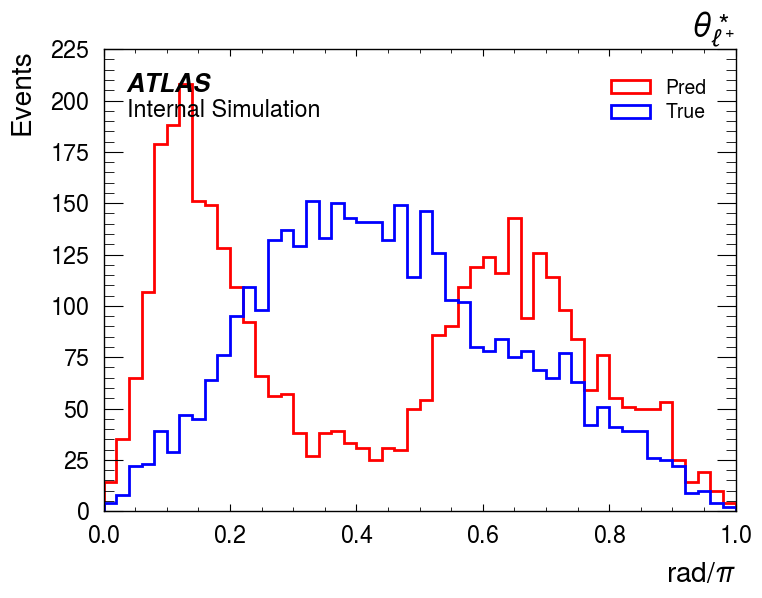

l+ theta RMSE: 0.34264115428184766
Rel err < 20%: 15.02 %


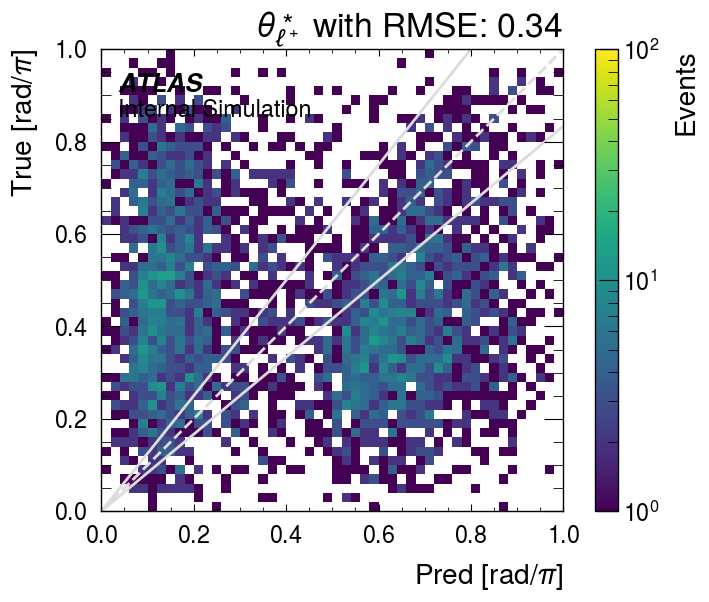

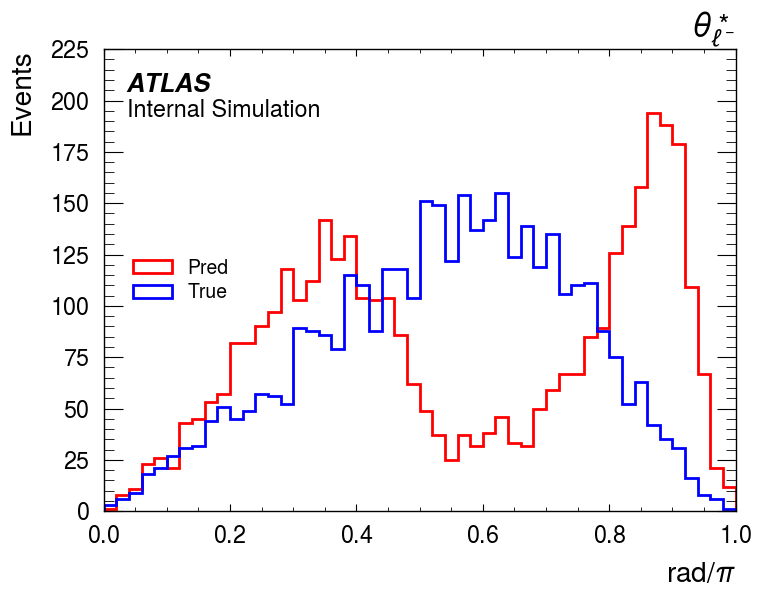

l- theta RMSE: 0.3433447323692524
Rel err < 20%: 18.33 %


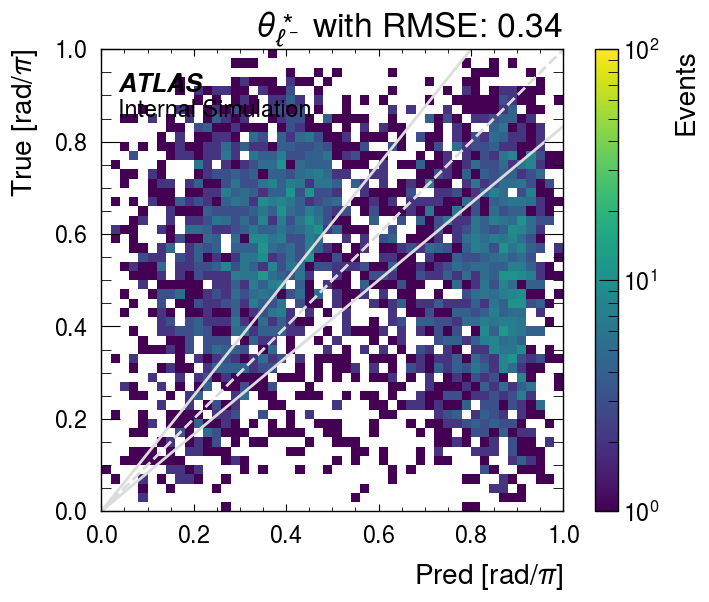

In [33]:
plot_1d_hist(pred_l0_theta_phi_swapped[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l+ theta RMSE:", rmse(pred_l0_theta_phi_swapped[0], true_l0_theta_phi[0]))
plot_2d_hist(pred_l0_theta_phi_swapped[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi_swapped[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l- theta RMSE:", rmse(pred_l1_theta_phi_swapped[0], true_l1_theta_phi[0]))
plot_2d_hist(pred_l1_theta_phi_swapped[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

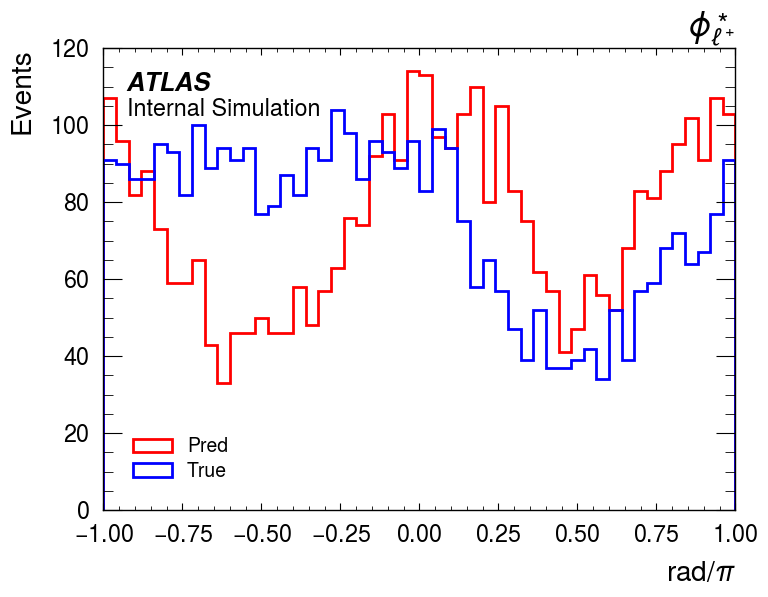

l+ phi RMSE: 0.8159389301770676
Rel err < 20%: 14.51 %


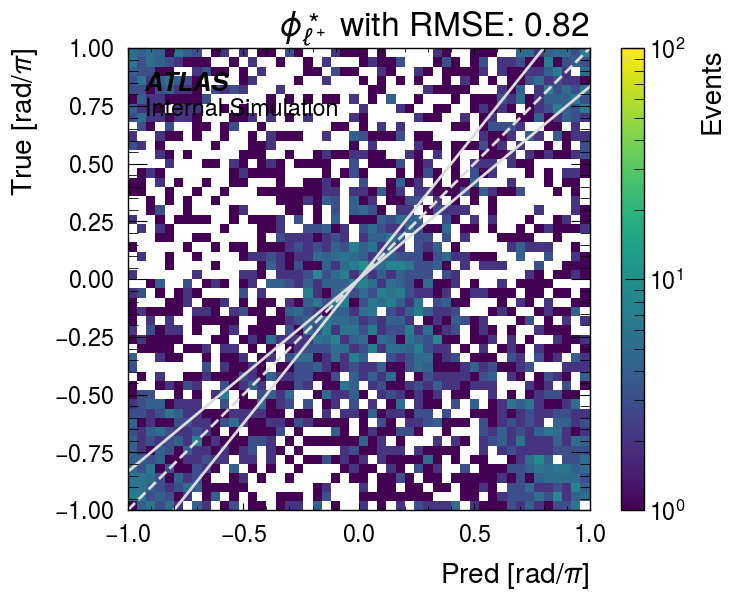

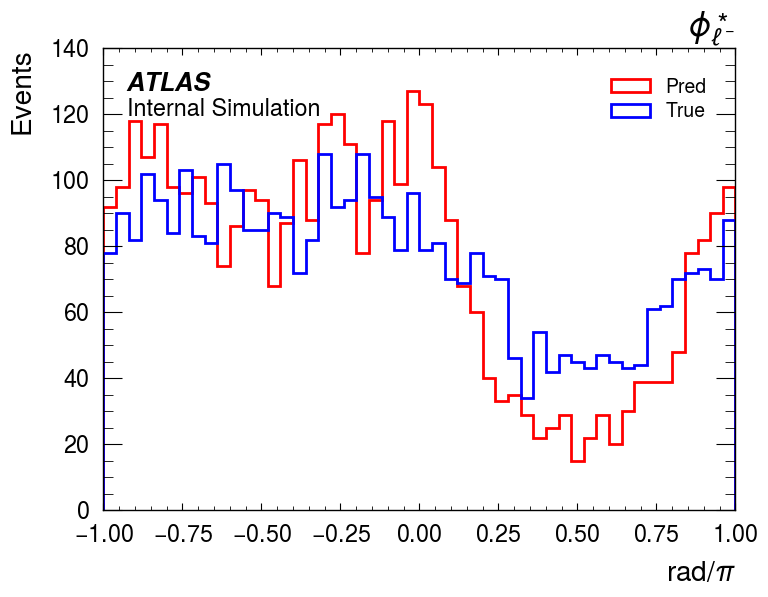

l- phi RMSE: 0.7908791385904272
Rel err < 20%: 15.65 %


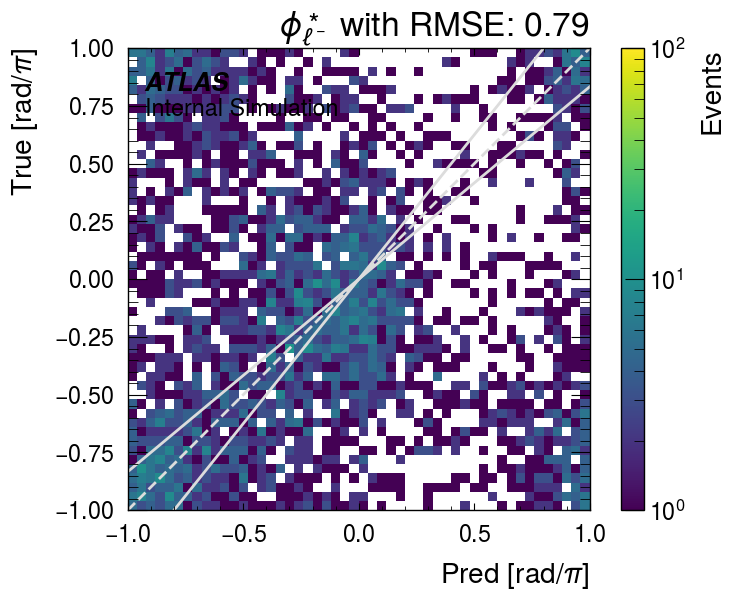

In [34]:
plot_1d_hist(pred_l0_theta_phi_swapped[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l+ phi RMSE:", rmse(pred_l0_theta_phi_swapped[1], true_l0_theta_phi[1]))
plot_2d_hist(pred_l0_theta_phi_swapped[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi_swapped[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l- phi RMSE:", rmse(pred_l1_theta_phi_swapped[1], true_l1_theta_phi[1]))
plot_2d_hist(pred_l1_theta_phi_swapped[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)